# 🌌 ExoProfiler — Análisis Exploratorio de Datos (EDA)

## 1. Preparación del análisis

Este notebook desarrolla el análisis exploratorio de datos (EDA) del proyecto ExoProfiler.

Tras comprender la estructura, disponibilidad y significado de las variables en la fase de Data Understanding, en esta etapa se estudia cómo se comportan y relacionan las características candidatas.

Los principales objetivos son:

- Analizar las distribuciones de las variables planetarias y estelares.
- Estudiar su asimetría y dispersión.
- Identificar y analizar valores potencialmente atípicos.
- Explorar las relaciones y correlaciones entre variables.
- Detectar posibles redundancias.
- Obtener evidencia para justificar posteriormente la selección y transformación de características antes del clustering.

Las decisiones de transformación, imputación y escalado no se aplicarán todavía en esta fase, sino que se justificarán posteriormente durante el preprocesamiento.

In [1]:
# Importamos las librerías necesarias para
# el análisis y la visualización de los datos.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos pandas para facilitar
# la visualización de los resultados.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Definimos la ruta al dataset original.
DATA_PATH = "../data/raw/exoplanets.csv"

# Cargamos el dataset.
#
# El archivo contiene líneas iniciales de metadatos
# identificadas mediante el símbolo "#".
# El parámetro comment="#" permite ignorarlas
# durante la lectura.
df = pd.read_csv(
    DATA_PATH,
    comment="#"
)

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

Dataset cargado: 910 filas y 92 columnas


In [3]:
planet_features = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt"
]

stellar_features = [
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg"
]

candidate_features = (
    planet_features
    + stellar_features
)

# Recuperamos las variables candidatas definidas durante
# la fase de Data Understanding.
#
# En este notebook analizaremos su comportamiento estadístico
# antes de decidir cuáles se utilizarán finalmente para clustering.

## 2. Análisis univariante de las variables planetarias
Una vez estudiada la disponibilidad de los datos, se analiza cómo se distribuyen los valores de las variables candidatas.

El estudio de las distribuciones permite detectar:

- Variables aproximadamente simétricas o fuertemente sesgadas.
- Diferencias importantes de escala.
- Concentraciones de observaciones en determinados rangos.
- Posibles valores extremos.
- Variables que podrían requerir transformaciones antes del clustering.

Este análisis es especialmente relevante porque algoritmos como K-Means utilizan distancias entre observaciones. Por tanto, la escala y distribución de las variables pueden influir considerablemente en la formación de los clusters.

En primer lugar se analizarán las variables relacionadas directamente con las propiedades físicas y orbitales de los exoplanetas.

### 2.1 Estadísticos descriptivos de las variables planetarias

Se calculan los principales estadísticos descriptivos de las variables planetarias candidatas.

Estos valores permiten conocer su tendencia central, dispersión y rango antes de analizar gráficamente sus distribuciones.

Se prestará especial atención a las diferencias entre la media y la mediana, así como a valores máximos muy alejados de los percentiles centrales, ya que pueden ser indicios de distribuciones asimétricas o de observaciones extremas.

In [4]:
# Calculamos los principales estadísticos descriptivos
# únicamente para las variables planetarias candidatas.
planet_descriptive = df[planet_features].describe().T

# Añadimos la mediana de forma explícita para facilitar
# su comparación con la media de cada variable.
planet_descriptive["median"] = df[planet_features].median()

# Seleccionamos y ordenamos los estadísticos
# más útiles para nuestra exploración.
planet_descriptive = planet_descriptive[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

planet_descriptive

,count,mean,median,std,min,25%,50%,75%,max
pl_orbper,907.0,16.796365,5.705880,100.204849,0.238182,3.347239,5.705880,11.514239,2890.000000
pl_orbsmax,704.0,0.100049,0.060040,0.197219,0.005626,0.037950,0.060040,0.105550,4.370000
pl_rade,897.0,5.923743,3.181755,4.960706,0.566000,2.265000,3.181755,10.500000,25.000000
pl_bmasse,620.0,337.292291,30.150000,926.820013,0.460000,7.700000,30.150000,255.851868,8899.195396
pl_orbeccen,623.0,0.106061,0.046000,0.152365,0.000000,0.000000,0.046000,0.150000,0.941200
pl_insol,386.0,383.054285,74.185000,672.777170,0.181000,18.670750,74.185000,557.000000,5300.000000
pl_eqt,670.0,965.632448,862.745000,476.450705,163.000000,596.000000,862.745000,1294.250000,3646.000000


### 2.2 Histogramas de las variables planetarias

Se utilizan histogramas para visualizar la distribución de cada característica planetaria.

Cada barra representa el número de exoplanetas cuyos valores se encuentran dentro de un determinado intervalo.

El objetivo es identificar posibles asimetrías, concentraciones de datos y colas extremas que puedan influir posteriormente en los algoritmos de clustering.

Los valores nulos se excluyen únicamente de cada visualización, sin modificar el dataset original.

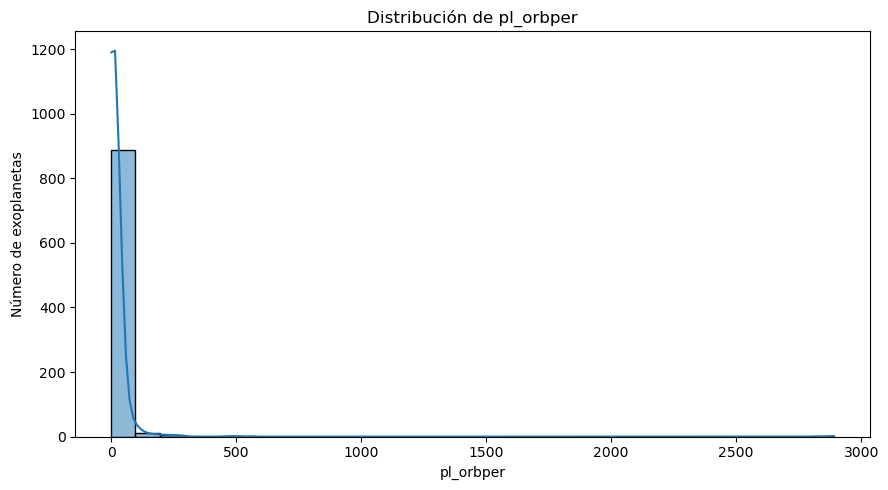

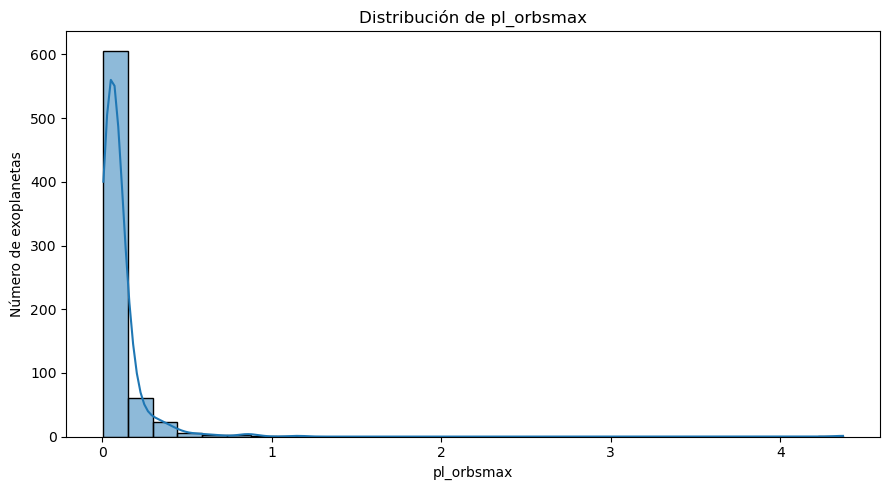

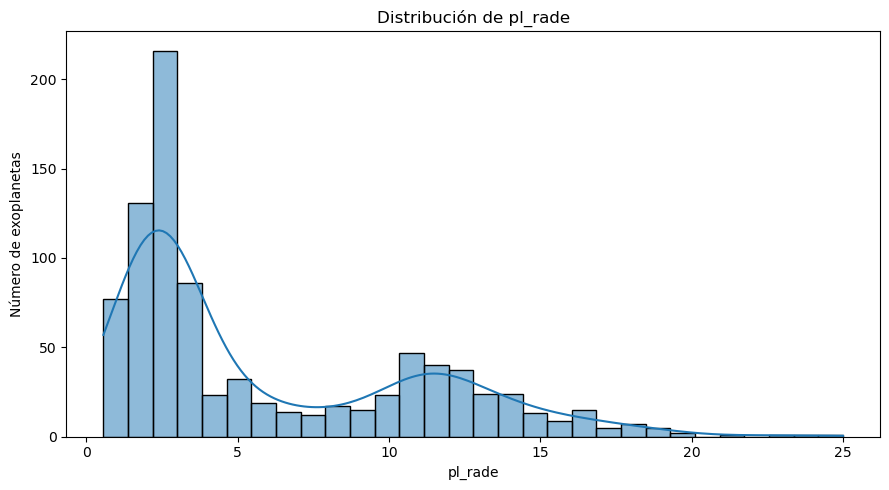

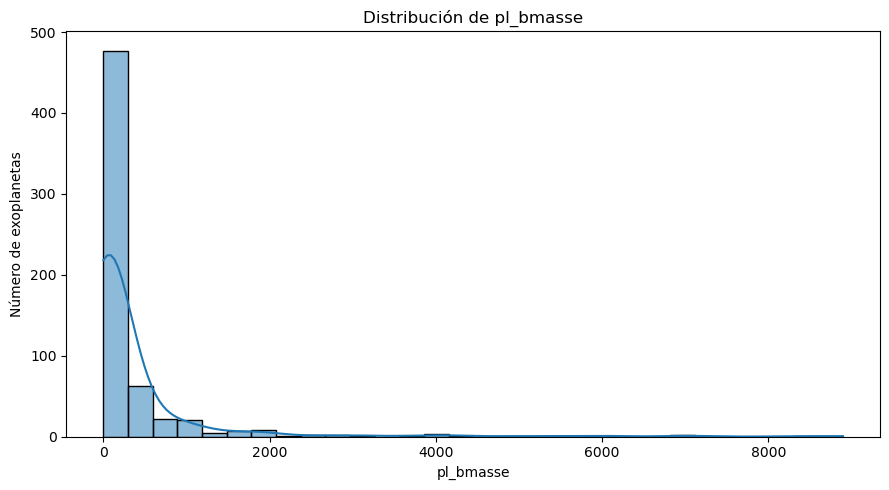

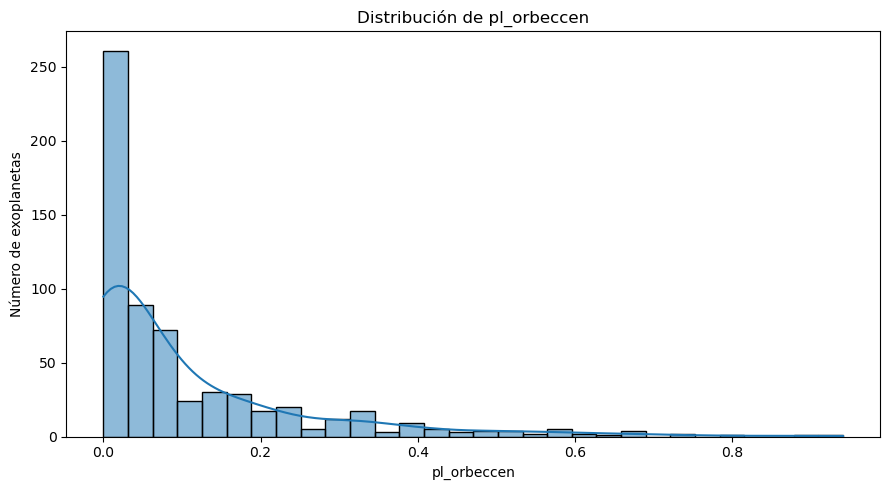

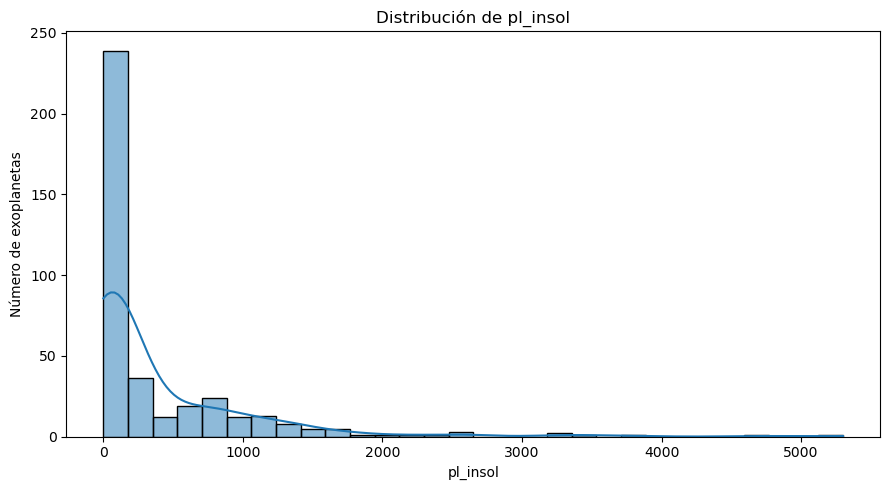

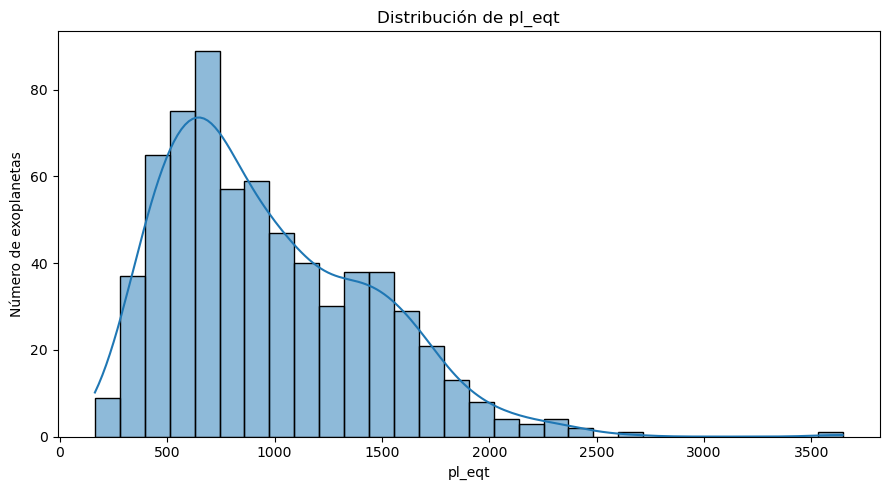

In [5]:
# Recorremos cada una de las variables planetarias
# para estudiar su distribución individualmente.
for feature in planet_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 5))

    # Eliminamos únicamente los valores nulos de la variable
    # que estamos representando para que no interfieran
    # en la construcción del histograma.
    data = df[feature].dropna()

    # Creamos el histograma.
    # kde=True añade una curva suavizada que ayuda
    # a visualizar la forma general de la distribución.
    sns.histplot(
        data=data,
        bins=30,
        kde=True
    )

    # Añadimos un título indicando la variable analizada.
    plt.title(
        f"Distribución de {feature}"
    )

    # Etiquetamos los ejes.
    plt.xlabel(feature)
    plt.ylabel("Número de exoplanetas")

    # Ajustamos el diseño para evitar solapamientos.
    plt.tight_layout()

    # Mostramos el gráfico.
    plt.show()

### 2.3 Interpretación inicial de las distribuciones planetarias

El análisis de las distribuciones muestra comportamientos considerablemente diferentes entre las características planetarias.

Las variables `pl_orbper`, `pl_orbsmax`, `pl_bmasse`, `pl_orbeccen` y `pl_insol` presentan distribuciones claramente asimétricas hacia la derecha. La mayoría de las observaciones se concentra en valores relativamente bajos, mientras que un número reducido de exoplanetas alcanza valores considerablemente superiores.

Estas diferencias son especialmente visibles al comparar la media y la mediana. Por ejemplo, en `pl_bmasse` la media es aproximadamente 337 masas terrestres, mientras que la mediana se sitúa alrededor de 30, lo que evidencia la influencia de valores extremadamente elevados.

Estos valores no deben considerarse automáticamente errores o eliminarse como outliers, ya que pueden representar objetos astronómicos reales con características poco frecuentes.

La variable `pl_rade` presenta un comportamiento especialmente interesante, con diferentes concentraciones visibles en determinados rangos de radio. Esto podría indicar la existencia de distintas poblaciones según el tamaño planetario, aunque será necesario estudiar esta estructura conjuntamente con otras variables antes de realizar cualquier interpretación como familia planetaria.

Por su parte, `pl_eqt` presenta una distribución menos extrema, aunque mantiene cierta asimetría positiva.

Estos resultados indican que varias variables podrían requerir transformaciones antes de aplicar algoritmos basados en distancias. Sin embargo, cualquier transformación se decidirá posteriormente durante el preprocesamiento y deberá estar justificada por los resultados completos del EDA.

### 2.4 Análisis cuantitativo de la asimetría

Además de la inspección visual mediante histogramas, se calcula el coeficiente de asimetría (*skewness*) de las variables planetarias.

Esta métrica permite cuantificar si una distribución es aproximadamente simétrica o si presenta una cola más pronunciada hacia alguno de sus extremos.

De forma orientativa:

- Valores cercanos a 0 indican una distribución aproximadamente simétrica.
- Valores positivos indican una cola hacia valores altos.
- Valores negativos indican una cola hacia valores bajos.
- Cuanto mayor sea el valor absoluto del coeficiente, mayor será la asimetría.

Este análisis ayudará posteriormente a valorar si determinadas variables pueden beneficiarse de transformaciones antes de aplicar algoritmos de clustering basados en distancias.

In [6]:
# Calculamos el coeficiente de asimetría de cada
# variable planetaria candidata.
planet_skewness = (
    df[planet_features]
    .skew()
    .sort_values(ascending=False)
)

# Convertimos el resultado en un DataFrame
# para facilitar su lectura e interpretación.
planet_skewness_df = planet_skewness.to_frame(
    name="skewness"
)

planet_skewness_df

,skewness
pl_orbper,26.279213
pl_orbsmax,15.260370
pl_bmasse,5.540018
pl_insol,3.377534
pl_orbeccen,2.221235
pl_rade,1.005324
pl_eqt,0.905856


## 3. Análisis de valores extremos

Los boxplots permiten estudiar la dispersión de las variables e identificar observaciones que se encuentran alejadas del rango central de la distribución.

De forma convencional, un valor puede considerarse potencialmente atípico cuando se encuentra por debajo de `Q1 - 1,5 × IQR` o por encima de `Q3 + 1,5 × IQR`, donde IQR representa el rango intercuartílico.

Sin embargo, en este proyecto un valor estadísticamente atípico no se considerará automáticamente un error.

La diversidad física de los exoplanetas puede producir observaciones extremadamente diferentes pero científicamente válidas. Estos objetos podrían incluso representar grupos minoritarios relevantes para el clustering.

Por este motivo, los valores extremos serán identificados y analizados antes de decidir cualquier tratamiento.

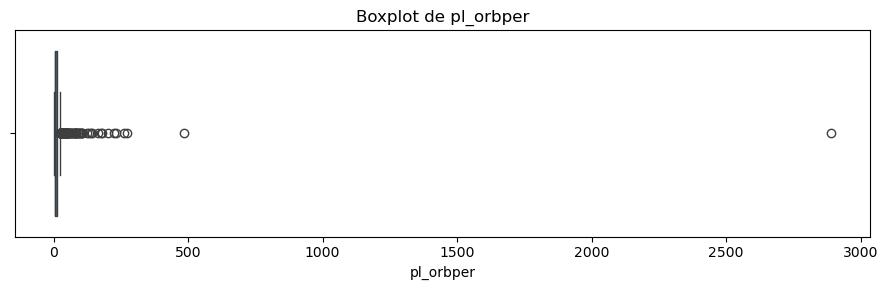

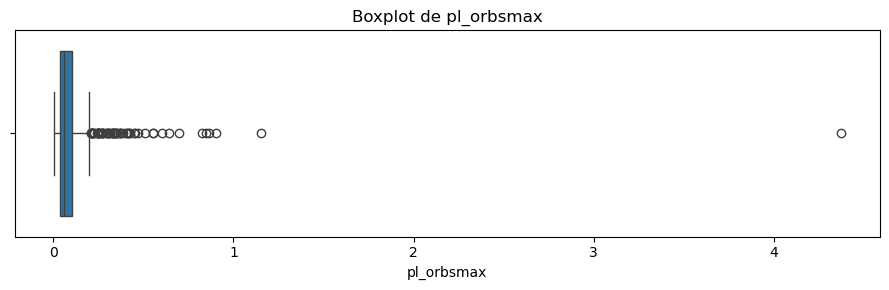

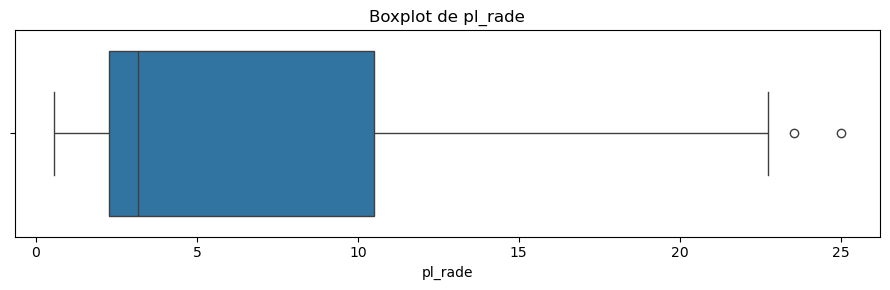

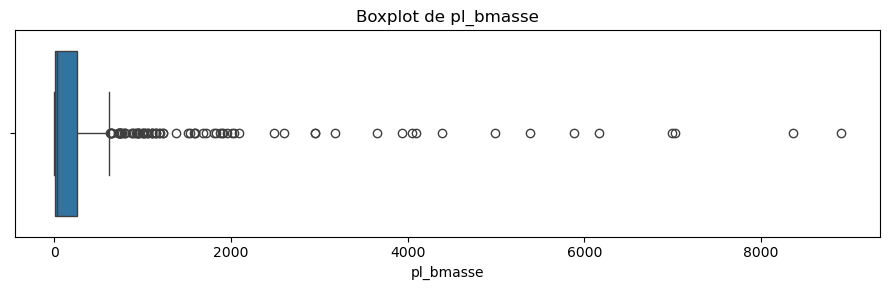

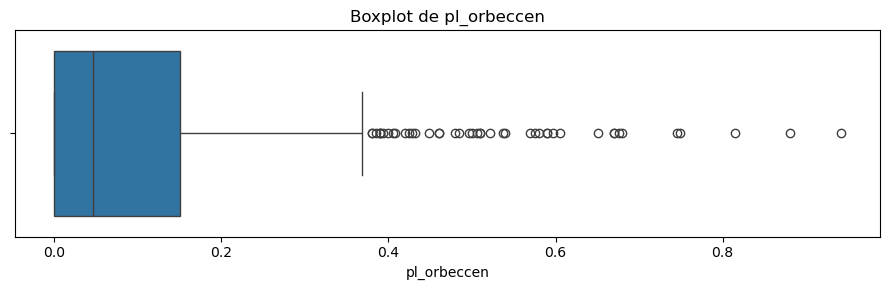

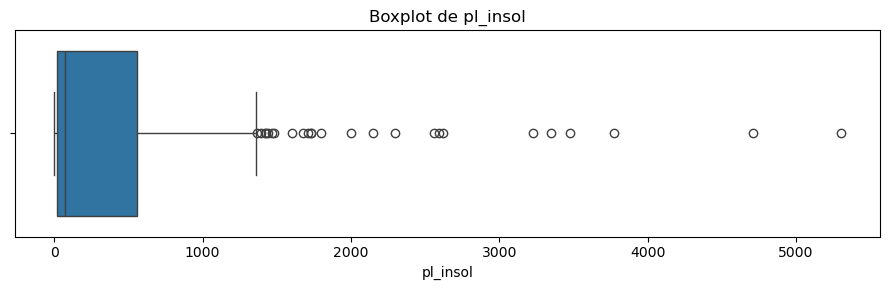

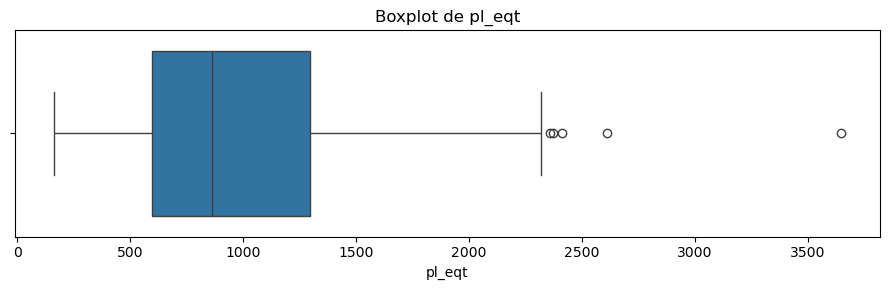

In [7]:
# Recorremos las variables planetarias para visualizar
# individualmente su dispersión y posibles valores extremos.
for feature in planet_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 3))

    # Generamos el boxplot utilizando únicamente
    # los valores disponibles de la variable.
    sns.boxplot(
        x=df[feature].dropna()
    )

    # Añadimos un título descriptivo.
    plt.title(
        f"Boxplot de {feature}"
    )

    # Etiquetamos el eje horizontal.
    plt.xlabel(feature)

    # Ajustamos el diseño.
    plt.tight_layout()

    # Mostramos el gráfico.
    plt.show()

### 3.1 Interpretación de la asimetría y los valores extremos

El análisis cuantitativo confirma que todas las variables planetarias presentan algún grado de asimetría positiva, aunque con intensidades muy diferentes.

Las mayores asimetrías aparecen en `pl_orbper` y `pl_orbsmax`, con coeficientes de skewness de aproximadamente 26,28 y 15,26 respectivamente. Estos valores reflejan una fuerte concentración de observaciones en rangos bajos y la existencia de una cola muy extensa hacia valores superiores.

`pl_bmasse`, `pl_insol` y `pl_orbeccen` también presentan asimetrías elevadas, mientras que `pl_rade` y especialmente `pl_eqt` muestran distribuciones menos extremas.

Los boxplots identifican numerosos valores estadísticamente atípicos en varias características. Sin embargo, estos valores no se eliminarán automáticamente.

En un contexto astrofísico, una observación alejada del rango central puede representar un planeta con características físicas poco frecuentes y no necesariamente un error de medición. Eliminar estos objetos sin analizarlos podría reducir artificialmente la diversidad del dataset y afectar precisamente a la identificación de grupos minoritarios mediante clustering.

Por este motivo, los valores extremos se analizarán cuantitativamente y su tratamiento se decidirá posteriormente en función de su naturaleza, distribución y efecto sobre los algoritmos de clustering.

### 3.2 Identificación cuantitativa mediante el método IQR

Para cuantificar la presencia de valores potencialmente atípicos se utiliza el método del rango intercuartílico (IQR).

El IQR se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

`IQR = Q3 - Q1`

De forma convencional, se consideran potencialmente atípicos los valores situados fuera del intervalo:

- Límite inferior: `Q1 - 1,5 × IQR`
- Límite superior: `Q3 + 1,5 × IQR`

Este criterio se utilizará únicamente como herramienta descriptiva. Las observaciones detectadas no serán eliminadas automáticamente, ya que pueden representar exoplanetas físicamente válidos con características poco frecuentes.

In [8]:
# Creamos una lista vacía donde almacenaremos
# los resultados del análisis de cada variable.
outlier_summary = []

# Analizamos individualmente cada variable planetaria.
for feature in planet_features:

    # Eliminamos temporalmente los valores nulos únicamente
    # para poder calcular correctamente los cuartiles.
    data = df[feature].dropna()

    # Calculamos el primer y tercer cuartil.
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    # Calculamos el rango intercuartílico (IQR),
    # que contiene el 50 % central de los datos.
    iqr = q3 - q1

    # Calculamos los límites convencionales utilizados
    # para identificar posibles valores atípicos.
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # Identificamos qué observaciones se encuentran
    # fuera de los límites calculados.
    outliers = data[
        (data < lower_limit) |
        (data > upper_limit)
    ]

    # Calculamos qué porcentaje representan respecto
    # a los valores disponibles de esa variable.
    outlier_percentage = (
        len(outliers) / len(data)
    ) * 100

    # Guardamos los resultados para construir
    # posteriormente una tabla resumen.
    outlier_summary.append({
        "variable": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": lower_limit,
        "limite_superior": upper_limit,
        "n_outliers_IQR": len(outliers),
        "porcentaje_outliers": round(
            outlier_percentage, 2
        )
    })

# Convertimos los resultados en un DataFrame
# para facilitar su interpretación.
outlier_summary_df = pd.DataFrame(
    outlier_summary
)

outlier_summary_df

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers_IQR,porcentaje_outliers
0,pl_orbper,3.347239,11.514239,8.167001,-8.903262,23.764741,97,10.69
1,pl_orbsmax,0.037950,0.105550,0.067600,-0.063450,0.206950,59,8.38
2,pl_rade,2.265000,10.500000,8.235000,-10.087500,22.852500,2,0.22
3,pl_bmasse,7.700000,255.851868,248.151868,-364.527801,628.079669,78,12.58
4,pl_orbeccen,0.000000,0.150000,0.150000,-0.225000,0.375000,44,7.06
5,pl_insol,18.670750,557.000000,538.329250,-788.823125,1364.493875,25,6.48
6,pl_eqt,596.000000,1294.250000,698.250000,-451.375000,2341.625000,5,0.75


### 3.3 Conclusiones sobre los valores potencialmente atípicos

La aplicación del criterio IQR muestra diferencias importantes entre las variables planetarias.

`pl_bmasse` y `pl_orbper` presentan las mayores proporciones de observaciones clasificadas como potencialmente atípicas, con aproximadamente un 12,58 % y un 10,69 % respectivamente. También se identifican porcentajes relevantes en `pl_orbsmax`, `pl_orbeccen` y `pl_insol`.

Estos resultados son coherentes con las fuertes asimetrías observadas previamente en sus distribuciones.

Por el contrario, `pl_rade` y `pl_eqt` presentan porcentajes muy reducidos de valores fuera de los límites establecidos por el criterio IQR.

No se eliminarán automáticamente las observaciones identificadas como atípicas.

El método IQR identifica valores estadísticamente alejados del rango central de una distribución, pero no permite determinar por sí mismo si dichos valores son errores. En un dataset de exoplanetas, algunos de estos casos pueden corresponder a objetos reales con propiedades físicas poco frecuentes.

Además, eliminar estos valores podría reducir artificialmente la diversidad del dataset y eliminar posibles grupos minoritarios que podrían resultar relevantes para el clustering.

Por tanto, se conservarán inicialmente estas observaciones y se estudiará posteriormente el uso de transformaciones y técnicas de escalado adecuadas para reducir la influencia desproporcionada de las distribuciones extremas sobre las métricas de distancia.

## 4. Análisis de las variables estelares

Además de las propiedades directamente relacionadas con los exoplanetas, el conjunto inicial de características candidatas incluye información sobre sus estrellas anfitrionas.

Las propiedades de la estrella pueden aportar contexto relevante sobre el entorno en el que se encuentra cada planeta.

Las variables analizadas son:

- `st_teff`: temperatura efectiva de la estrella.
- `st_rad`: radio estelar.
- `st_mass`: masa estelar.
- `st_met`: metalicidad.
- `st_logg`: gravedad superficial.

Se analizarán sus distribuciones, asimetría y presencia de valores extremos siguiendo los mismos criterios utilizados anteriormente para las variables planetarias.

Posteriormente se estudiarán las relaciones entre todas las características candidatas para determinar si algunas variables contienen información redundante.

### 4.1 Estadísticos descriptivos de las variables estelares

Se calculan los principales estadísticos descriptivos de las variables relacionadas con las estrellas anfitrionas.

El objetivo es estudiar su tendencia central, dispersión y rango, siguiendo el mismo enfoque aplicado previamente a las características planetarias.

In [9]:
# Calculamos los principales estadísticos descriptivos
# de las variables relacionadas con la estrella anfitriona.
stellar_descriptive = df[stellar_features].describe().T

# Añadimos explícitamente la mediana para poder compararla
# fácilmente con la media de cada característica.
stellar_descriptive["median"] = (
    df[stellar_features].median()
)

# Seleccionamos los estadísticos más relevantes
# para el análisis exploratorio.
stellar_descriptive = stellar_descriptive[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

stellar_descriptive

,count,mean,median,std,min,25%,50%,75%,max
st_teff,885.0,5053.029266,5315.0000,1019.216501,2850.0000,4201.930,5315.0000,5823.0000,8500.000
st_rad,905.0,0.964791,0.8660,0.510088,0.0131,0.657,0.8660,1.2000,4.100
st_mass,787.0,0.866176,0.8889,0.339001,0.1180,0.630,0.8889,1.1000,1.900
st_met,685.0,0.054527,0.0600,0.201011,-0.6600,-0.070,0.0600,0.1900,0.790
st_logg,821.0,4.470500,4.4870,0.310413,3.2440,4.290,4.4870,4.6361,7.915


### 4.2 Distribuciones de las variables estelares

Se analizan visualmente las distribuciones de las características estelares mediante histogramas.

Este análisis permite identificar posibles asimetrías, concentraciones de observaciones y diferencias en la forma de las distribuciones.

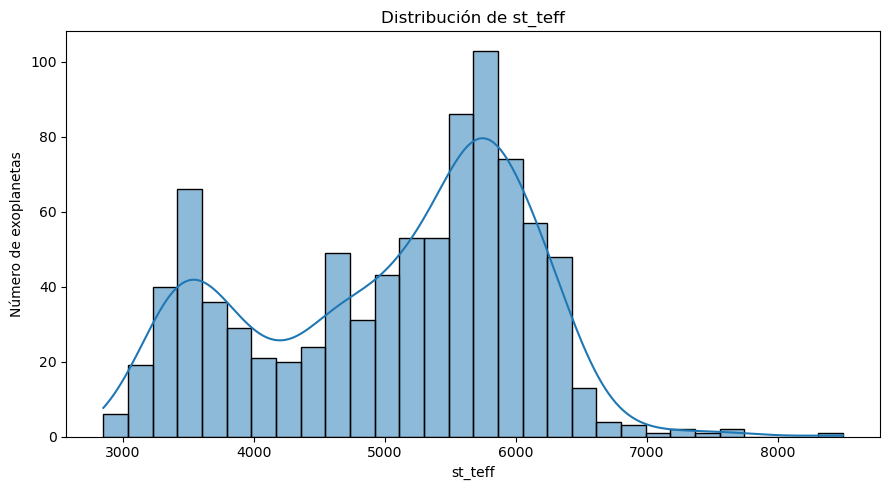

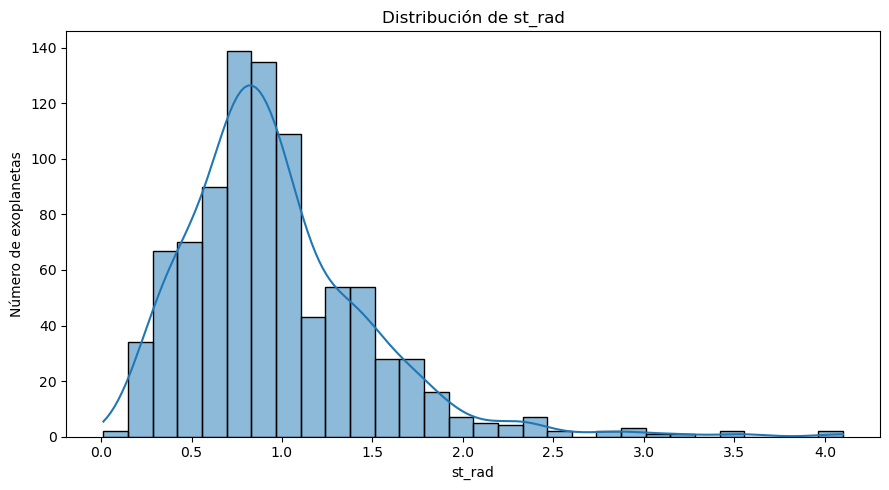

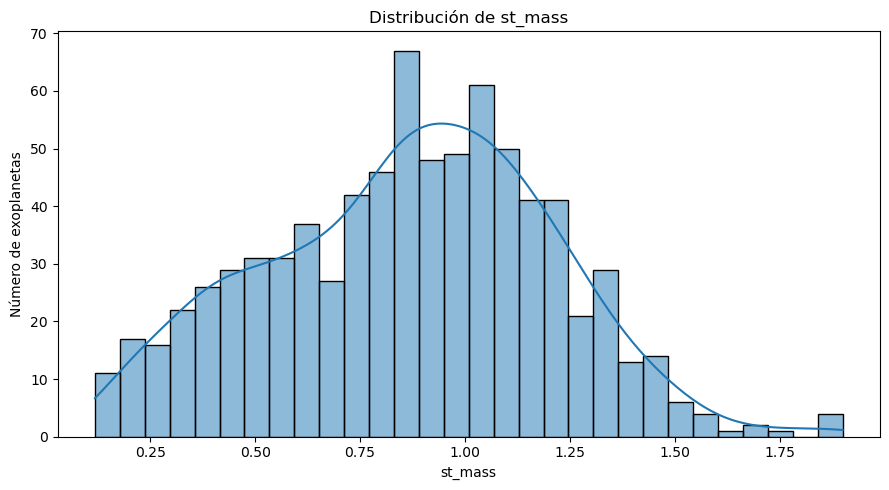

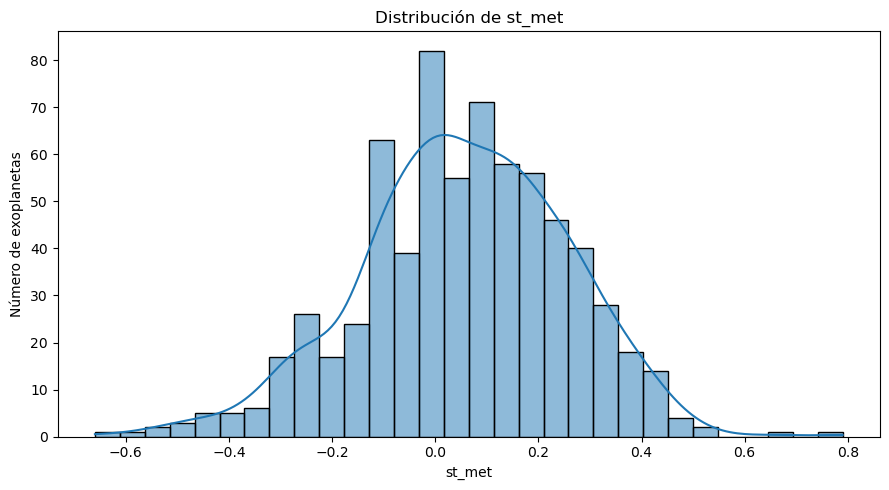

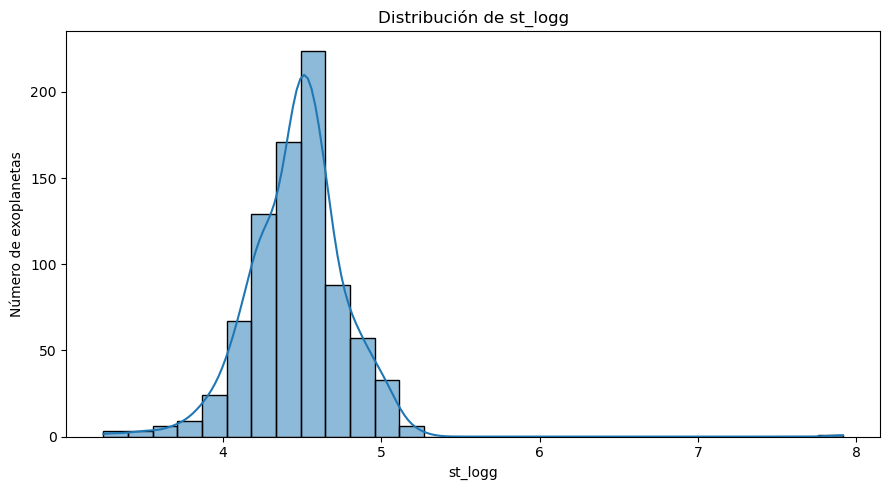

In [10]:
# Recorremos cada variable estelar para analizar
# visualmente la forma de su distribución.
for feature in stellar_features:

    # Creamos una figura independiente para cada variable.
    plt.figure(figsize=(9, 5))

    # Eliminamos únicamente los valores nulos de la variable
    # representada, sin modificar el DataFrame original.
    data = df[feature].dropna()

    # Creamos el histograma y añadimos una estimación
    # suavizada de la densidad mediante KDE.
    sns.histplot(
        data=data,
        bins=30,
        kde=True
    )

    # Añadimos títulos y etiquetas descriptivas.
    plt.title(f"Distribución de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Número de exoplanetas")

    # Ajustamos y mostramos el gráfico.
    plt.tight_layout()
    plt.show()

### 4.3 Análisis cuantitativo de la asimetría

Se calcula el coeficiente de asimetría de las variables estelares para complementar la inspección visual de sus distribuciones.

Los resultados permitirán comparar su comportamiento con el observado previamente en las características planetarias.

In [11]:
# Calculamos el coeficiente de asimetría
# de cada variable estelar.
stellar_skewness = (
    df[stellar_features]
    .skew()
    .sort_values(ascending=False)
)

# Convertimos el resultado en una tabla
# para facilitar su interpretación.
stellar_skewness_df = stellar_skewness.to_frame(
    name="skewness"
)

stellar_skewness_df

,skewness
st_rad,1.645483
st_logg,1.314813
st_mass,-0.037888
st_met,-0.238448
st_teff,-0.359925


### 4.4 Análisis visual de valores extremos

Se utilizan boxplots para estudiar la dispersión de las variables estelares e identificar observaciones estadísticamente alejadas de sus distribuciones principales.

Al igual que en las variables planetarias, estas observaciones no se considerarán automáticamente errores y serán interpretadas dentro de su contexto físico.

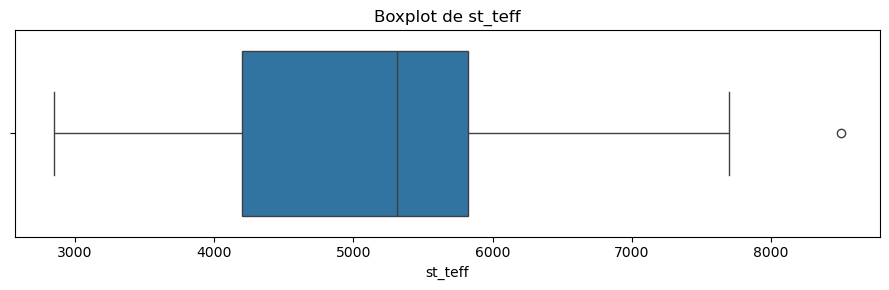

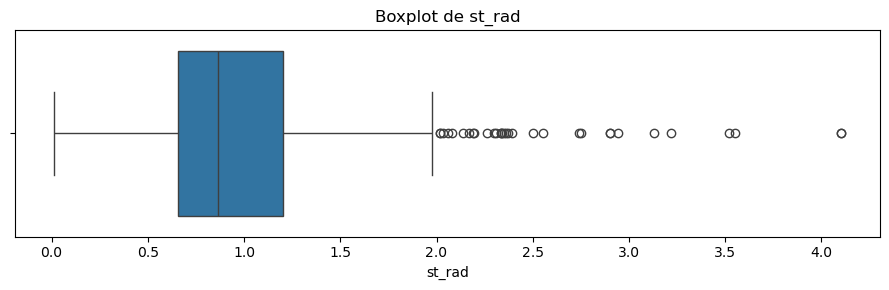

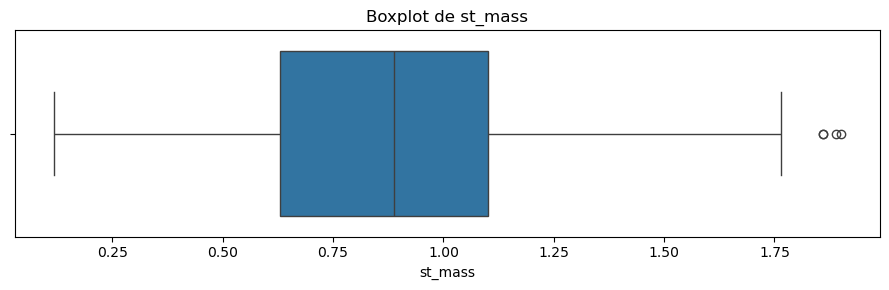

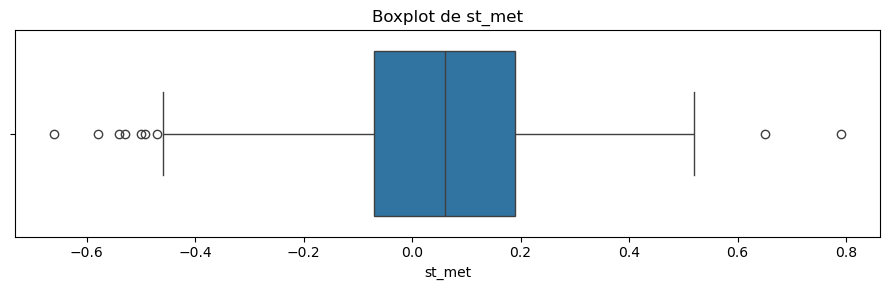

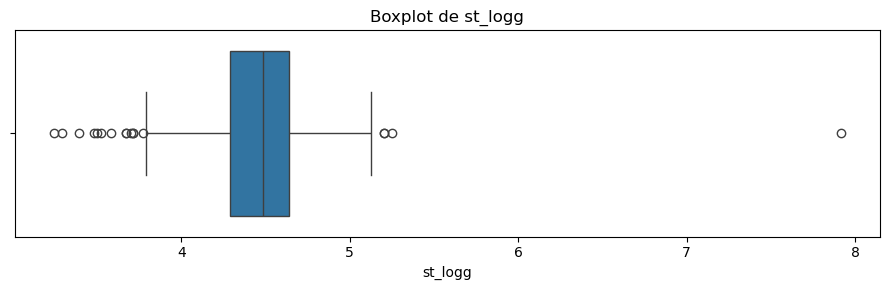

In [12]:
# Creamos un boxplot independiente para cada
# variable estelar con el objetivo de estudiar
# su dispersión y posibles valores extremos.
for feature in stellar_features:

    plt.figure(figsize=(9, 3))

    # Los valores nulos se excluyen únicamente
    # para construir correctamente el gráfico.
    sns.boxplot(
        x=df[feature].dropna()
    )

    plt.title(f"Boxplot de {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

### 4.5 Inspección de valores extremos destacados

La inspección visual de las variables estelares muestra un valor especialmente alejado del resto de observaciones en `st_logg`.

A diferencia de otras variables donde existe una cola progresiva de valores elevados, este caso aparece claramente aislado respecto a la distribución principal.

Antes de decidir cualquier tratamiento, se inspeccionará la observación correspondiente y el resto de sus características para determinar si existen indicios de un posible valor anómalo o si puede tratarse de una observación físicamente válida.

In [13]:
# Localizamos las observaciones con los valores más altos
# de gravedad superficial estelar (st_logg).
#
# No eliminamos ningún registro: únicamente inspeccionamos
# los casos extremos para comprender mejor su contexto.
df.nlargest(
    5,
    "st_logg"
)[
    [
        "pl_name",
        "st_logg",
        "st_mass",
        "st_rad",
        "st_teff"
    ]
]

,pl_name,st_logg,st_mass,st_rad,st_teff
907,WD 1856+534 b,7.915,0.518,0.0131,4710.0
15,Gliese 12 b,5.250,0.255,0.2650,3328.0
56,HD 260655 b,5.200,0.439,0.4390,3803.0
57,HD 260655 c,5.200,0.439,0.4390,3803.0
109,LP 890-9 b,5.126,0.118,0.1556,2850.0


#### Análisis del valor extremo de `st_logg`

La inspección individual de las observaciones con mayor gravedad superficial muestra que el valor máximo de `st_logg` (7,915) corresponde al sistema **WD 1856+534 b**.

Este registro presenta también un radio estelar (`st_rad = 0,0131`) extremadamente reducido en comparación con el resto de la muestra.

La estrella anfitriona de este sistema podría ser una enana blanca, un tipo de remanente estelar caracterizado por concentrar una masa considerable en un radio muy pequeño. Por tanto, una gravedad superficial elevada resulta físicamente coherente con sus características.

Este caso demuestra que un valor estadísticamente extremo no debe considerarse automáticamente un error.

Por este motivo, la observación no será eliminada del dataset. La decisión sobre si `st_logg` debe formar parte de las variables utilizadas para clustering se realizará posteriormente en función de su utilidad, cobertura y relación con otras características.

### 4.6 Conclusiones del análisis de las variables estelares

Las variables relacionadas con las estrellas anfitrionas presentan, en general, distribuciones menos extremas que las observadas en varias características planetarias.

`st_mass`, `st_met` y `st_teff` muestran coeficientes de asimetría relativamente próximos a cero, especialmente `st_mass`, cuya media y mediana son también muy similares.

`st_rad` presenta una asimetría positiva más marcada y una cola formada por estrellas de mayor tamaño. Estos valores no se consideran automáticamente errores, ya que pueden corresponder a diferencias físicas reales entre las estrellas anfitrionas.

La distribución de `st_teff` muestra distintas concentraciones de observaciones en determinados rangos de temperatura, un patrón que podría resultar relevante al estudiar posteriormente la estructura conjunta de los datos.

En `st_logg` se observa un valor especialmente alejado de la distribución principal. Debido a su carácter aislado, esta observación ha sido inspeccionada individualmente antes de decidir cualquier posible tratamiento.

En conjunto, las variables estelares presentan distribuciones estadísticamente más moderadas que algunas características planetarias. No obstante, su utilidad final para el clustering dependerá también de su cobertura, sus relaciones con otras variables y la posible existencia de información redundante.

## 5. Análisis de relaciones entre variables

Tras estudiar individualmente las características planetarias y estelares, se analizan las relaciones existentes entre las variables candidatas.

El objetivo es identificar posibles asociaciones fuertes y detectar características que puedan contener información redundante.

Este análisis es especialmente relevante para el clustering, ya que incluir varias variables que representen información muy similar podría aumentar artificialmente el peso de una determinada dimensión al calcular distancias entre observaciones.

Se estudiarán tanto correlaciones lineales mediante el coeficiente de **Pearson** como relaciones monotónicas mediante **Spearman**.

La comparación entre ambos métodos resulta especialmente útil en este dataset debido a las fuertes asimetrías y valores extremos detectados previamente en varias variables.

Las correlaciones se utilizarán como herramienta exploratoria para apoyar la selección posterior de características. Una correlación elevada no implicará automáticamente la eliminación de una variable, sino que deberá interpretarse junto con su significado físico, cobertura y utilidad para el objetivo del proyecto.

### 5.1 Cálculo de las matrices de correlación

Para estudiar las relaciones entre las variables candidatas se calculan dos matrices de correlación diferentes:

- **Pearson:** mide principalmente la intensidad de las relaciones lineales entre dos variables.
- **Spearman:** mide si dos variables tienden a aumentar o disminuir conjuntamente siguiendo una relación monotónica, utilizando para ello el orden o rango de los valores.

La comparación entre ambos métodos es relevante porque durante el análisis univariante se detectaron distribuciones fuertemente asimétricas y numerosos valores extremos en algunas características.

Los coeficientes de correlación toman valores entre **-1 y 1**:

- Valores próximos a **1** indican una relación positiva fuerte: cuando una variable aumenta, la otra tiende a aumentar.
- Valores próximos a **-1** indican una relación negativa fuerte: cuando una aumenta, la otra tiende a disminuir.
- Valores próximos a **0** indican una relación débil o ausencia de una relación clara del tipo que mide el coeficiente.

Estas correlaciones se utilizarán como herramienta exploratoria y no implican necesariamente una relación causal entre las variables.

In [14]:
# Seleccionamos únicamente las variables candidatas para el clustering.
#
# No incluimos identificadores como el nombre del planeta ni otras
# columnas que no forman parte de nuestro análisis de características.
correlation_data = df[candidate_features]


# Calculamos la matriz de correlación de Pearson.
#
# Pearson mide principalmente relaciones LINEALES:
# analiza si dos variables cambian de forma proporcional entre sí.
pearson_corr = correlation_data.corr(
    method="pearson"
)


# Calculamos la matriz de correlación de Spearman.
#
# Spearman trabaja con el ORDEN o RANGO de los valores en lugar
# de depender directamente de sus magnitudes originales.
#
# Esto lo hace especialmente interesante en nuestro dataset,
# donde hemos detectado variables muy asimétricas y valores extremos.
spearman_corr = correlation_data.corr(
    method="spearman"
)


print("Dimensiones de la matriz de Pearson:", pearson_corr.shape)
print("Dimensiones de la matriz de Spearman:", spearman_corr.shape)

Dimensiones de la matriz de Pearson: (12, 12)
Dimensiones de la matriz de Spearman: (12, 12)


### 5.2 Número de observaciones disponibles por pareja de variables

Debido a la presencia de valores ausentes, no todas las correlaciones se calculan utilizando el mismo número de observaciones.

Pandas calcula cada correlación utilizando únicamente las filas donde ambas variables de la pareja tienen valores disponibles.

Por este motivo, antes de interpretar la intensidad de las correlaciones, se calcula también el número de observaciones utilizadas en cada comparación.

Esto permitirá distinguir entre correlaciones respaldadas por una muestra amplia y relaciones calculadas a partir de un número más reducido de observaciones.

In [15]:
# Creamos una tabla vacía con las mismas variables
# en filas y columnas que nuestra matriz de correlación.
pair_counts = pd.DataFrame(
    index=candidate_features,
    columns=candidate_features,
    dtype=int
)


# Recorremos todas las combinaciones posibles de variables.
for var_1 in candidate_features:
    for var_2 in candidate_features:

        # Seleccionamos las dos variables y eliminamos únicamente
        # las filas donde falta alguno de esos dos valores.
        #
        # De esta forma sabemos cuántos planetas se utilizarían
        # realmente para calcular la correlación entre esa pareja.
        n_complete_pairs = (
            df[[var_1, var_2]]
            .dropna()
            .shape[0]
        )

        # Guardamos el número de observaciones disponibles.
        pair_counts.loc[var_1, var_2] = n_complete_pairs


# Convertimos los resultados a números enteros
# para facilitar su lectura.
pair_counts = pair_counts.astype(int)

pair_counts

,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
pl_orbper,907,704,896,620,623,386,669,885,905,787,685,821
pl_orbsmax,704,704,696,563,571,375,617,685,702,700,618,635
pl_rade,896,696,897,610,614,386,662,874,894,776,675,811
pl_bmasse,620,563,610,620,570,299,549,601,618,617,588,589
pl_orbeccen,623,571,614,570,623,296,535,604,621,620,581,580
pl_insol,386,375,386,299,296,386,346,378,386,381,328,340
pl_eqt,669,617,662,549,535,346,670,655,668,663,607,630
st_teff,885,685,874,601,604,378,655,885,885,769,685,821
st_rad,905,702,894,618,621,386,668,885,905,787,685,821
st_mass,787,700,776,617,620,381,663,769,787,787,685,705


### 5.3 Identificación de las correlaciones más fuertes

Las matrices de correlación contienen todas las combinaciones posibles entre las variables, incluyendo relaciones duplicadas y la correlación de cada variable consigo misma.

Para facilitar su interpretación, se construye una tabla con cada pareja de variables una única vez.

Para cada relación se muestran:

- El coeficiente de correlación de **Pearson**.
- El coeficiente de correlación de **Spearman**.
- El número de observaciones disponibles para calcular dicha relación.

La comparación entre Pearson y Spearman permitirá detectar casos en los que las distribuciones asimétricas, los valores extremos o la forma de la relación provoquen diferencias importantes entre ambos coeficientes.

In [16]:
# Creamos una lista donde guardaremos cada pareja
# de variables una única vez.
correlation_pairs = []


# Recorremos las variables candidatas.
for i, var_1 in enumerate(candidate_features):

    # Empezamos desde i + 1 para evitar:
    #
    # 1. Comparar una variable consigo misma.
    # 2. Repetir parejas.
    #
    # Por ejemplo, si ya tenemos:
    # pl_orbper ↔ pl_rade
    #
    # no necesitamos guardar también:
    # pl_rade ↔ pl_orbper
    for var_2 in candidate_features[i + 1:]:

        correlation_pairs.append({
            "variable_1": var_1,
            "variable_2": var_2,

            # Recuperamos la correlación calculada
            # mediante el método de Pearson.
            "pearson": pearson_corr.loc[
                var_1,
                var_2
            ],

            # Recuperamos la correlación calculada
            # mediante el método de Spearman.
            "spearman": spearman_corr.loc[
                var_1,
                var_2
            ],

            # Añadimos también el número de observaciones
            # disponibles para esta pareja concreta.
            "n_observaciones": pair_counts.loc[
                var_1,
                var_2
            ]
        })


# Convertimos los resultados en un DataFrame
# para poder analizarlos fácilmente.
correlation_pairs_df = pd.DataFrame(
    correlation_pairs
)

correlation_pairs_df.head()

,variable_1,variable_2,pearson,spearman,n_observaciones
0,pl_orbper,pl_orbsmax,0.942005,0.972128,704
1,pl_orbper,pl_rade,0.057737,0.108733,896
2,pl_orbper,pl_bmasse,0.234371,0.075174,620
3,pl_orbper,pl_orbeccen,0.199294,0.324841,623
4,pl_orbper,pl_insol,-0.162575,-0.490839,386


In [17]:
# Calculamos el valor absoluto de Spearman.
#
# Nos interesa medir la FUERZA de la relación
# independientemente de si es positiva o negativa.
correlation_pairs_df["abs_spearman"] = (
    correlation_pairs_df["spearman"].abs()
)


# Ordenamos las parejas desde la relación
# monotónica más fuerte hasta la más débil.
strongest_correlations = (
    correlation_pairs_df
    .sort_values(
        by="abs_spearman",
        ascending=False
    )
    .reset_index(drop=True)
)


# Mostramos las 15 relaciones más fuertes.
strongest_correlations[
    [
        "variable_1",
        "variable_2",
        "pearson",
        "spearman",
        "n_observaciones"
    ]
].head(15)

,variable_1,variable_2,pearson,spearman,n_observaciones
0,pl_insol,pl_eqt,0.836441,0.991460,346
1,pl_orbper,pl_orbsmax,0.942005,0.972128,704
2,st_rad,st_mass,0.857516,0.965682,787
3,st_rad,st_logg,-0.886353,-0.958383,821
4,st_teff,st_mass,0.946449,0.950829,769
5,st_teff,st_rad,0.734420,0.922851,885
6,st_mass,st_logg,-0.816684,-0.913068,705
7,pl_rade,pl_bmasse,0.328812,0.886048,610
8,st_teff,st_logg,-0.721843,-0.861753,821
9,pl_insol,st_rad,0.551696,0.740792,386


### 5.4 Comparación entre las correlaciones de Pearson y Spearman

La comparación entre ambos coeficientes permite identificar relaciones cuyo comportamiento puede no ser adecuadamente representado mediante una relación lineal.

Una diferencia elevada entre Pearson y Spearman puede estar asociada a:

- relaciones monotónicas pero no lineales;
- distribuciones fuertemente asimétricas;
- presencia de valores extremos;
- diferentes escalas o concentraciones de observaciones.

Estas diferencias son especialmente relevantes antes del clustering, ya que ayudan a comprender la estructura real de los datos antes de aplicar transformaciones o seleccionar características.

In [18]:
# Calculamos la diferencia absoluta entre ambos coeficientes.
#
# No nos importa aquí cuál de los dos es mayor,
# sino CUÁNTO difieren en su interpretación de la relación.
correlation_pairs_df["difference"] = (
    correlation_pairs_df["spearman"]
    - correlation_pairs_df["pearson"]
).abs()


# Ordenamos las parejas desde la mayor diferencia
# entre Pearson y Spearman hasta la menor.
correlation_differences = (
    correlation_pairs_df
    .sort_values(
        by="difference",
        ascending=False
    )
    .reset_index(drop=True)
)


# Mostramos las 10 parejas donde ambos métodos
# presentan mayores diferencias.
correlation_differences[
    [
        "variable_1",
        "variable_2",
        "pearson",
        "spearman",
        "difference",
        "n_observaciones"
    ]
].head(10)

,variable_1,variable_2,pearson,spearman,difference,n_observaciones
0,pl_rade,pl_bmasse,0.328812,0.886048,0.557235,610
1,pl_bmasse,st_logg,-0.112995,-0.506210,0.393215,589
2,pl_bmasse,st_met,0.093125,0.437780,0.344655,588
3,pl_bmasse,st_rad,0.223554,0.553554,0.330001,618
4,pl_orbper,pl_insol,-0.162575,-0.490839,0.328264,386
5,pl_bmasse,st_mass,0.247904,0.564233,0.316329,617
6,pl_bmasse,st_teff,0.210588,0.498017,0.287429,601
7,pl_bmasse,pl_insol,0.126988,0.414020,0.287031,299
8,pl_insol,st_logg,-0.471012,-0.722175,0.251164,340
9,pl_orbsmax,st_rad,0.126775,0.366535,0.239760,702


#### Interpretación de las diferencias entre Pearson y Spearman

La mayor discrepancia se observa entre `pl_rade` y `pl_bmasse`. Mientras Pearson muestra una correlación relativamente débil (0.329), Spearman identifica una relación monotónica fuerte (0.886).

Además, `pl_bmasse` aparece repetidamente entre las parejas con mayores diferencias entre ambos coeficientes.

Este comportamiento es coherente con los resultados del análisis univariante, donde `pl_bmasse` mostró una distribución fuertemente asimétrica, presencia de valores extremos y una gran diferencia entre su media y mediana.

Estos resultados sugieren que algunas relaciones asociadas a la masa planetaria podrían no ser adecuadamente representadas mediante una relación lineal simple.

Por este motivo, se realizará una inspección visual de las relaciones más relevantes antes de tomar decisiones sobre posibles transformaciones o selección de características.

### 5.5 Visualización de relaciones especialmente relevantes

A partir del análisis de correlaciones se seleccionan algunas relaciones especialmente relevantes para su inspección visual.

Se priorizan tres situaciones diferentes:

1. **`pl_orbper` y `pl_orbsmax`:** presentan una correlación muy elevada tanto en Pearson como en Spearman, lo que podría indicar información parcialmente redundante.

2. **`pl_insol` y `pl_eqt`:** muestran una relación monotónica prácticamente perfecta, pero presentan diferencias importantes en su disponibilidad de datos.

3. **`pl_rade` y `pl_bmasse`:** muestran una gran diferencia entre Pearson y Spearman, lo que sugiere una relación fuerte pero posiblemente no lineal y afectada por la distribución de los datos.

La inspección visual permitirá comprender mejor estas relaciones antes de tomar decisiones sobre la selección o transformación de variables.

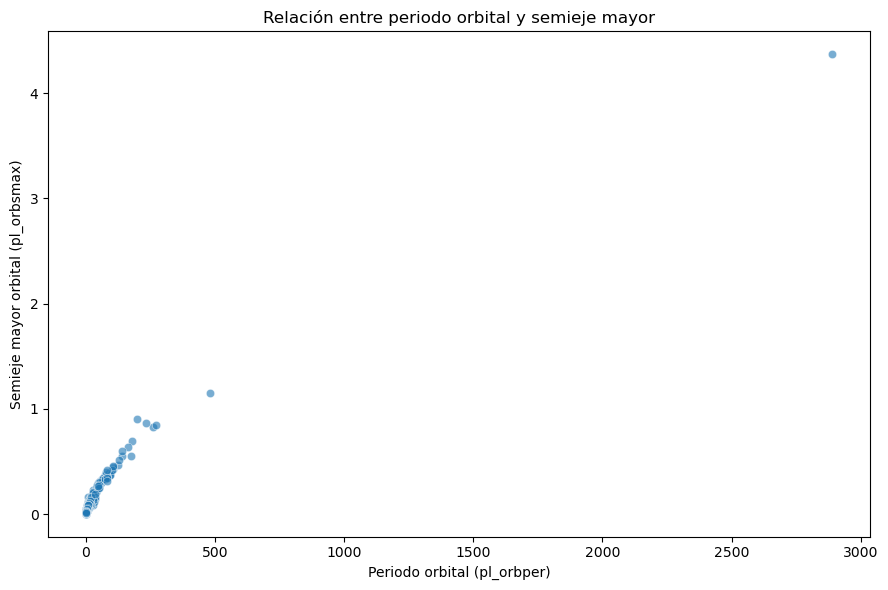

In [19]:
# Seleccionamos únicamente las observaciones que tienen
# disponibles ambas variables.
plot_data = df[
    ["pl_orbper", "pl_orbsmax"]
].dropna()


# Representamos cada exoplaneta como un punto.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_data,
    x="pl_orbper",
    y="pl_orbsmax",
    alpha=0.6
)

plt.title(
    "Relación entre periodo orbital y semieje mayor"
)

plt.xlabel(
    "Periodo orbital (pl_orbper)"
)

plt.ylabel(
    "Semieje mayor orbital (pl_orbsmax)"
)

plt.tight_layout()
plt.show()

#### Interpretación: `pl_orbper` y `pl_orbsmax`

El periodo orbital (`pl_orbper`) y el semieje mayor (`pl_orbsmax`) presentan una relación positiva muy fuerte, coherente tanto en Pearson (0.942) como en Spearman (0.972), calculada sobre 704 observaciones.

La visualización muestra, sin embargo, una fuerte concentración de observaciones en valores bajos y unas pocas observaciones extremas que amplían considerablemente la escala de ambos ejes.

Este comportamiento es coherente con la elevada asimetría detectada previamente en ambas variables.

La fuerte asociación entre estas características sugiere además que podrían aportar información parcialmente redundante al clustering. No obstante, cualquier decisión sobre su selección se realizará posteriormente considerando también su significado físico, cobertura y comportamiento tras posibles transformaciones.

#### Relación entre radio y masa planetaria

La relación entre el radio planetario (`pl_rade`) y la masa planetaria (`pl_bmasse`) presenta la mayor diferencia observada entre los coeficientes de Pearson y Spearman.

Mientras Pearson indica una relación lineal relativamente débil (0.329), Spearman muestra una asociación monotónica fuerte (0.886).

Esta discrepancia podría estar relacionada con la existencia de una relación no lineal, con la fuerte asimetría previamente detectada en `pl_bmasse` o con la influencia de valores extremos.

Se realiza una inspección visual para comprender mejor el comportamiento conjunto de ambas variables.

Número de observaciones: 610


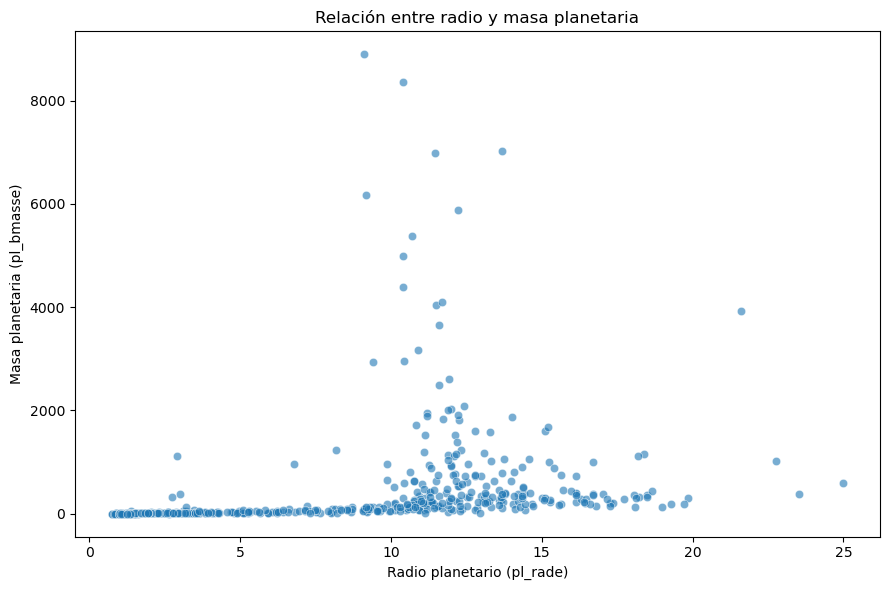

In [20]:
# Seleccionamos únicamente los exoplanetas que disponen
# simultáneamente de radio y masa planetaria.
#
# De esta forma trabajamos con las mismas observaciones
# utilizadas para estudiar la relación entre ambas variables.
mass_radius_data = df[
    ["pl_rade", "pl_bmasse"]
].dropna()


print(
    "Número de observaciones:",
    len(mass_radius_data)
)


# Representamos la relación utilizando primero
# las escalas originales de ambas variables.
#
# Cada punto representa un exoplaneta.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=mass_radius_data,
    x="pl_rade",
    y="pl_bmasse",
    alpha=0.6
)

plt.title(
    "Relación entre radio y masa planetaria"
)

plt.xlabel(
    "Radio planetario (pl_rade)"
)

plt.ylabel(
    "Masa planetaria (pl_bmasse)"
)

plt.tight_layout()
plt.show()

#### Interpretación en escala original

La representación en escala original muestra una fuerte concentración de observaciones en valores relativamente bajos de masa planetaria, junto con un conjunto reducido de planetas que alcanzan masas de varios miles de masas terrestres.

Estos valores amplían considerablemente el rango del eje de masa y dificultan la visualización de la estructura seguida por la mayoría de las observaciones.

Este comportamiento es coherente con el análisis univariante previo de `pl_bmasse`, donde se detectó una distribución fuertemente asimétrica, una diferencia considerable entre media y mediana y numerosos valores extremos según el criterio IQR.

La forma observada también ayuda a explicar la diferencia entre Pearson (0.329) y Spearman (0.886). La relación entre radio y masa no parece estar adecuadamente representada mediante una relación lineal simple, mientras que Spearman detecta una fuerte asociación monotónica entre el orden de ambas variables.

No se consideran estas observaciones extremas como errores ni se eliminan automáticamente, ya que pueden representar planetas físicamente válidos.

#### Relación entre insolación y temperatura de equilibrio

La insolación recibida por un planeta (`pl_insol`) y su temperatura de equilibrio (`pl_eqt`) presentan una de las asociaciones más fuertes detectadas en el análisis de correlaciones.

Los coeficientes obtenidos fueron:

- **Pearson: 0.836**
- **Spearman: 0.991**

La correlación de Spearman, prácticamente perfecta, indica que ambas variables siguen una relación monotónica positiva extremadamente fuerte: cuando aumenta la energía recibida por el planeta, su temperatura de equilibrio tiende también a aumentar.

Esta relación resulta especialmente relevante para la selección posterior de características, ya que ambas variables podrían estar aportando información parcialmente redundante.

Además, presentan una diferencia importante en su disponibilidad:

- `pl_insol`: 386 valores disponibles.
- `pl_eqt`: 670 valores disponibles.

Por este motivo, se analiza visualmente su relación antes de valorar su posible impacto en la construcción del dataset destinado al clustering.

Número de observaciones con ambas variables: 346


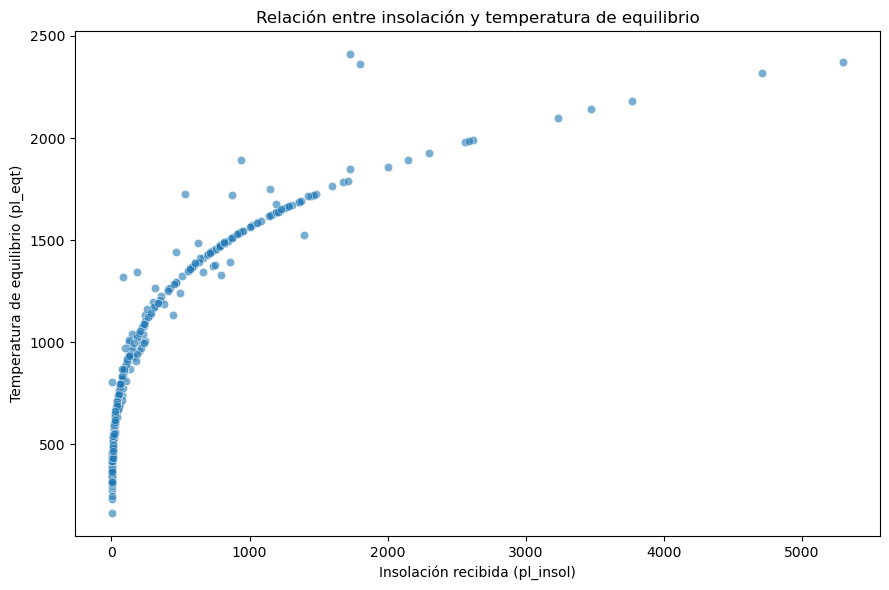

In [21]:
# Seleccionamos únicamente las observaciones que disponen
# simultáneamente de valores de insolación y temperatura
# de equilibrio.
#
# Esto garantiza que cada punto del gráfico representa
# un planeta con información disponible en ambas variables.
insol_eqt_data = df[
    ["pl_insol", "pl_eqt"]
].dropna()


# Comprobamos cuántos planetas pueden utilizarse
# para estudiar directamente esta relación.
print(
    "Número de observaciones con ambas variables:",
    len(insol_eqt_data)
)


# Representamos la relación entre la insolación recibida
# y la temperatura de equilibrio en su escala original.
#
# Cada punto representa un exoplaneta.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=insol_eqt_data,
    x="pl_insol",
    y="pl_eqt",
    alpha=0.6
)

plt.title(
    "Relación entre insolación y temperatura de equilibrio"
)

plt.xlabel(
    "Insolación recibida (pl_insol)"
)

plt.ylabel(
    "Temperatura de equilibrio (pl_eqt)"
)

plt.tight_layout()
plt.show()

#### Interpretación de la relación entre insolación y temperatura de equilibrio

La visualización muestra una relación positiva, muy fuerte y claramente no lineal entre la insolación recibida (`pl_insol`) y la temperatura de equilibrio (`pl_eqt`).

A medida que aumenta la insolación, la temperatura de equilibrio también aumenta de forma muy consistente, aunque siguiendo una trayectoria curva en lugar de una relación lineal simple.

Este comportamiento explica la diferencia entre los coeficientes obtenidos. Spearman alcanza un valor prácticamente perfecto (0.991) porque detecta una relación monotónica muy fuerte, mientras que Pearson presenta un valor algo menor (0.836) debido al carácter no lineal de la relación.

La fuerte asociación indica que ambas variables contienen información térmica estrechamente relacionada. Esto podría generar cierta redundancia si ambas se incorporasen simultáneamente al clustering.

Además, `pl_insol` presenta una disponibilidad considerablemente menor que `pl_eqt`, por lo que será necesario valorar si la información adicional que aporta compensa la pérdida potencial de observaciones.

En esta fase del EDA no se elimina ninguna variable; estos resultados se utilizarán posteriormente para justificar la selección de características durante el preprocessing.

### 5.6 Exploración visual mediante escala logarítmica

Las variables `pl_orbper` y `pl_orbsmax` presentan distribuciones fuertemente asimétricas y abarcan varios órdenes de magnitud.

En la escala original, unas pocas observaciones extremas comprimen visualmente la mayoría de los datos en una pequeña región del gráfico.

Para estudiar mejor la estructura de la relación, se representa el mismo scatterplot utilizando escalas logarítmicas en ambos ejes.

Este cambio afecta únicamente a la visualización y no modifica los datos originales.

La escala logarítmica permite representar de forma más equilibrada variables con rangos muy amplios y facilita la identificación de patrones que pueden quedar ocultos en la escala original.

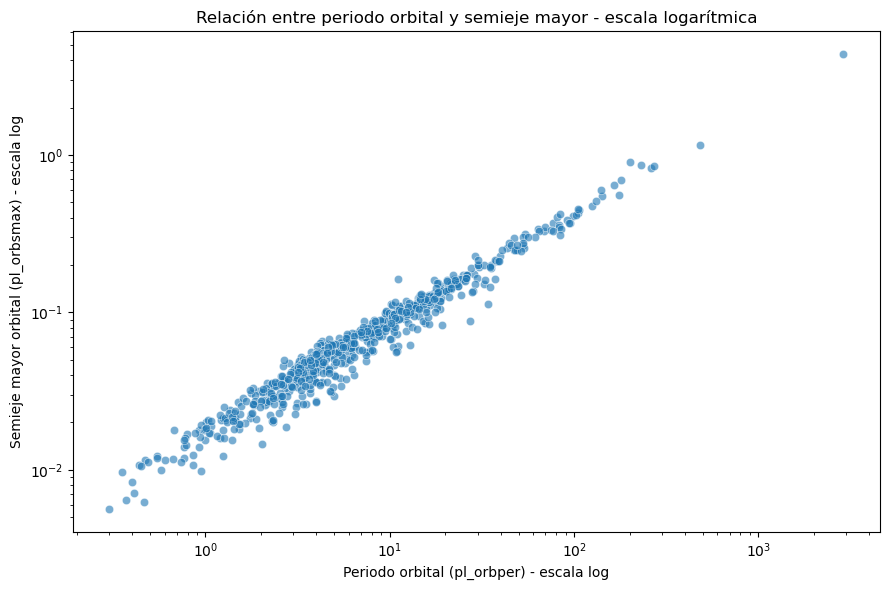

In [22]:
# Utilizamos los mismos datos del scatterplot anterior.
#
# No transformamos ni modificamos el DataFrame original:
# únicamente cambiaremos la escala visual de los ejes.

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_data,
    x="pl_orbper",
    y="pl_orbsmax",
    alpha=0.6
)


# Aplicamos escala logarítmica al eje X.
#
# Esto permite visualizar mejor valores que abarcan
# varios órdenes de magnitud.
plt.xscale("log")


# Aplicamos también escala logarítmica al eje Y.
plt.yscale("log")


plt.title(
    "Relación entre periodo orbital y semieje mayor - escala logarítmica"
)

plt.xlabel(
    "Periodo orbital (pl_orbper) - escala log"
)

plt.ylabel(
    "Semieje mayor orbital (pl_orbsmax) - escala log"
)

plt.tight_layout()
plt.show()

#### Interpretación de la visualización en escala logarítmica

Al representar `pl_orbper` y `pl_orbsmax` mediante escalas logarítmicas, la estructura de la relación se observa con mucha mayor claridad que en la escala original.

Los exoplanetas siguen una tendencia positiva muy definida: a medida que aumenta el periodo orbital, también tiende a aumentar el semieje mayor de la órbita.

La comparación con el gráfico en escala original demuestra que la fuerte asimetría de ambas variables y la presencia de observaciones de gran magnitud comprimían visualmente la mayoría de los datos.

La elevada asociación observada, respaldada también por Pearson (0.942) y Spearman (0.972), sugiere que ambas características contienen información estrechamente relacionada.

Además, la mejora obtenida mediante la escala logarítmica indica que podría ser conveniente evaluar posteriormente una transformación logarítmica de estas variables durante el preprocessing, antes del escalado y del clustering.

No obstante, en esta fase del EDA no se modifica el dataset ni se elimina ninguna de las dos variables.

#### Relación entre radio y masa planetaria en escala logarítmica

En la escala original, la relación entre el radio planetario (`pl_rade`) y la masa planetaria (`pl_bmasse`) se encontraba fuertemente condicionada por la amplia diferencia de magnitud entre las observaciones, especialmente en la variable de masa.

Además, esta pareja presentó la mayor discrepancia entre los coeficientes de Pearson (0.329) y Spearman (0.886), lo que sugiere que su relación no queda bien representada mediante una asociación lineal simple.

Por este motivo, se representa nuevamente la relación utilizando escalas logarítmicas en ambos ejes. El objetivo es reducir visualmente la compresión provocada por los valores de gran magnitud y observar con mayor claridad la estructura conjunta de ambas variables.

Este cambio afecta únicamente a la visualización y no modifica los datos originales.

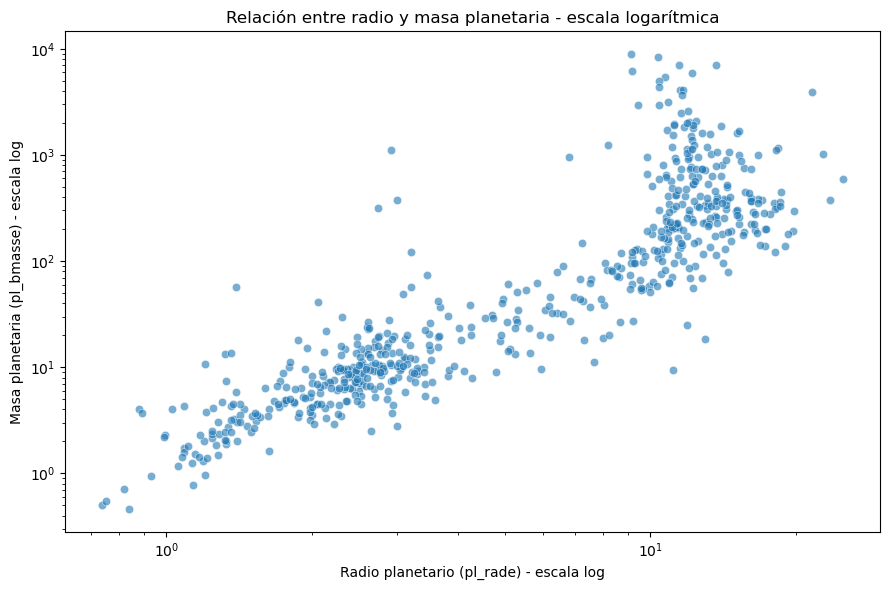

In [23]:
# Representamos la misma relación utilizando escalas
# logarítmicas en ambos ejes.
#
# No modificamos los datos originales del DataFrame.
# El cambio afecta únicamente a la visualización.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=mass_radius_data,
    x="pl_rade",
    y="pl_bmasse",
    alpha=0.6
)


# Aplicamos escala logarítmica al radio planetario.
plt.xscale("log")


# Aplicamos escala logarítmica a la masa planetaria.
#
# Esto permite reducir visualmente el efecto de las grandes
# diferencias de magnitud presentes en pl_bmasse.
plt.yscale("log")


plt.title(
    "Relación entre radio y masa planetaria - escala logarítmica"
)

plt.xlabel(
    "Radio planetario (pl_rade) - escala log"
)

plt.ylabel(
    "Masa planetaria (pl_bmasse) - escala log"
)

plt.tight_layout()
plt.show()

#### Interpretación de la relación radio-masa en escala logarítmica

La representación en escala logarítmica permite observar con mayor claridad la estructura de la relación entre el radio (`pl_rade`) y la masa planetaria (`pl_bmasse`), que quedaba parcialmente oculta en la escala original debido al amplio rango de valores de masa.

Se aprecia una tendencia positiva clara: en términos generales, los planetas de mayor radio tienden también a presentar una mayor masa. Este patrón es coherente con la elevada correlación de Spearman observada previamente (0.886).

Sin embargo, la relación no sigue una estructura lineal simple y presenta una dispersión considerable, especialmente entre los planetas de mayor radio. Existen cuerpos con radios similares pero masas muy diferentes.

Esta estructura, junto con la fuerte asimetría y los valores extremos detectados previamente en `pl_bmasse`, ayuda a comprender por qué Pearson muestra una correlación considerablemente menor (0.329) que Spearman.

La mejora en la visualización obtenida mediante las escalas logarítmicas refuerza la conveniencia de evaluar posteriormente una posible transformación logarítmica de estas variables durante el preprocessing.

No obstante, la relación entre ambas variables no implica necesariamente que una deba eliminarse: radio y masa representan propiedades físicas diferentes y podrían aportar información relevante para identificar distintas familias de exoplanetas durante el clustering.

### 5.7 Impacto de variables altamente correlacionadas sobre la cobertura

El análisis de correlaciones ha identificado varias parejas de variables con asociaciones muy elevadas.

Una correlación alta no implica automáticamente que una variable deba eliminarse. Sin embargo, cuando dos características contienen información estrechamente relacionada y una de ellas presenta una elevada proporción de valores ausentes, su inclusión puede reducir considerablemente el número de observaciones disponibles para el clustering.

Se analiza especialmente el caso de `pl_insol` y `pl_eqt`, cuya correlación de Spearman alcanza 0.991, pero presentan una cobertura muy diferente.

El objetivo es cuantificar el impacto que tendría exigir ambas variables frente a utilizar únicamente la característica con mayor disponibilidad.

Este análisis no realiza todavía ninguna eliminación de variables, sino que aporta evidencia para la posterior selección de características.

In [24]:
# Calculamos cuántos planetas tienen disponible
# únicamente la temperatura de equilibrio.
n_eqt = df["pl_eqt"].notna().sum()


# Calculamos cuántos tienen disponible
# únicamente la insolación.
n_insol = df["pl_insol"].notna().sum()


# Calculamos cuántos planetas disponen simultáneamente
# de ambas variables.
#
# Si un modelo exigiera las dos características,
# únicamente estas observaciones podrían utilizarse
# sin imputar valores.
n_both = df[
    ["pl_eqt", "pl_insol"]
].dropna().shape[0]


# Creamos una tabla comparativa para visualizar
# claramente el impacto sobre la cobertura.
thermal_coverage = pd.DataFrame({
    "escenario": [
        "Solo pl_eqt disponible",
        "Solo pl_insol disponible",
        "pl_eqt + pl_insol disponibles"
    ],
    "planetas_disponibles": [
        n_eqt,
        n_insol,
        n_both
    ]
})


# Calculamos qué porcentaje del dataset original
# representa cada escenario.
thermal_coverage["porcentaje_dataset"] = (
    thermal_coverage["planetas_disponibles"]
    / len(df)
    * 100
).round(2)


thermal_coverage

,escenario,planetas_disponibles,porcentaje_dataset
0,Solo pl_eqt disponible,670,73.63
1,Solo pl_insol disponible,386,42.42
2,pl_eqt + pl_insol disponibles,346,38.02


In [25]:
# Calculamos cuántas observaciones potenciales se pierden
# al exigir que un planeta tenga disponible pl_insol
# además de pl_eqt.
planets_lost = n_eqt - n_both


# Calculamos qué porcentaje representa esta pérdida
# respecto a los planetas que disponen de pl_eqt.
percentage_lost = (
    planets_lost / n_eqt
) * 100


print(
    f"Planetas con pl_eqt disponibles: {n_eqt}"
)

print(
    f"Planetas con pl_eqt y pl_insol disponibles: {n_both}"
)

print(
    f"Planetas potencialmente perdidos al exigir ambas: {planets_lost}"
)

print(
    f"Reducción respecto a la cobertura de pl_eqt: "
    f"{percentage_lost:.2f} %"
)

Planetas con pl_eqt disponibles: 670
Planetas con pl_eqt y pl_insol disponibles: 346
Planetas potencialmente perdidos al exigir ambas: 324
Reducción respecto a la cobertura de pl_eqt: 48.36 %


#### Conclusión provisional sobre `pl_insol` y `pl_eqt`

El análisis conjunto de correlación y cobertura muestra que `pl_insol` y `pl_eqt` contienen información estrechamente relacionada, con una correlación de Spearman de 0.991.

Sin embargo, su disponibilidad es muy diferente. Mientras `pl_eqt` está disponible para 670 planetas (73.63 % del dataset), exigir simultáneamente `pl_eqt` y `pl_insol` reduce la muestra potencial a 346 observaciones (38.02 % del dataset).

Esto supone 324 observaciones menos respecto a la cobertura disponible de `pl_eqt`, una reducción aproximada del 48.36 %.

Estos resultados convierten a `pl_insol` en una variable candidata a ser revisada durante la selección de características. Su elevada proporción de valores ausentes y su fuerte asociación con `pl_eqt` podrían hacer que su inclusión no compensase la pérdida de cobertura y la posible redundancia introducida en el clustering.

No obstante, no se elimina ninguna variable durante esta fase del EDA. La decisión final deberá considerar conjuntamente la cobertura, el significado físico de cada característica, las relaciones con el resto de variables y la estrategia de tratamiento de valores ausentes utilizada durante el preprocessing.

### 5.8 Evaluación conjunta de las variables candidatas para clustering

Tras analizar individualmente las distribuciones, los valores ausentes, los valores extremos y las relaciones entre variables, se realiza una evaluación conjunta de las características candidatas.

El objetivo es identificar posibles dificultades antes de construir el dataset destinado al clustering, considerando simultáneamente:

- **Cobertura:** porcentaje de observaciones disponibles para cada variable.
- **Correlación:** posibles relaciones muy fuertes que puedan introducir información redundante.
- **Distribución:** presencia de asimetrías pronunciadas que puedan requerir transformaciones.
- **Valores extremos:** observaciones que podrían influir especialmente en algoritmos basados en distancias.
- **Significado físico:** información astronómica aportada por cada característica.

Esta evaluación no determina todavía la selección definitiva de variables. Su finalidad es resumir la evidencia obtenida durante el EDA y establecer recomendaciones que deberán validarse durante el preprocessing y el modelado.

In [26]:
# Creamos una tabla resumen para reunir algunos de los principales
# indicadores estudiados durante el EDA.
#
# Para cada variable candidata calculamos:
# - número de valores disponibles;
# - porcentaje de cobertura;
# - porcentaje de valores nulos;
# - asimetría (skewness).
#
# Esta tabla nos permitirá comparar las variables de forma conjunta
# antes de plantear decisiones de preprocessing.

feature_evaluation = pd.DataFrame({
    "variable": candidate_features
})


# Número de observaciones no nulas disponibles.
feature_evaluation["valores_disponibles"] = [
    df[col].notna().sum()
    for col in candidate_features
]


# Porcentaje del dataset que dispone de cada variable.
feature_evaluation["cobertura_pct"] = [
    df[col].notna().mean() * 100
    for col in candidate_features
]


# Porcentaje de valores ausentes.
feature_evaluation["nulos_pct"] = [
    df[col].isna().mean() * 100
    for col in candidate_features
]


# Calculamos la asimetría de cada distribución.
#
# Valores alejados de 0 indican distribuciones asimétricas.
# Una asimetría positiva elevada significa que existe una
# cola larga hacia valores altos.
feature_evaluation["skewness"] = [
    df[col].skew()
    for col in candidate_features
]


# Redondeamos únicamente para facilitar la lectura.
feature_evaluation[
    ["cobertura_pct", "nulos_pct", "skewness"]
] = feature_evaluation[
    ["cobertura_pct", "nulos_pct", "skewness"]
].round(2)


# Ordenamos de mayor a menor cobertura.
feature_evaluation = (
    feature_evaluation
    .sort_values(
        by="cobertura_pct",
        ascending=False
    )
    .reset_index(drop=True)
)


feature_evaluation

,variable,valores_disponibles,cobertura_pct,nulos_pct,skewness
0,pl_orbper,907,99.67,0.33,26.28
1,st_rad,905,99.45,0.55,1.65
2,pl_rade,897,98.57,1.43,1.01
3,st_teff,885,97.25,2.75,-0.36
4,st_logg,821,90.22,9.78,1.31
5,st_mass,787,86.48,13.52,-0.04
6,pl_orbsmax,704,77.36,22.64,15.26
7,st_met,685,75.27,24.73,-0.24
8,pl_eqt,670,73.63,26.37,0.91
9,pl_orbeccen,623,68.46,31.54,2.22


#### Relaciones especialmente fuertes entre variables

Para complementar el análisis de cobertura, se identifican las parejas de variables con una correlación absoluta de Spearman igual o superior a 0.85.

Este umbral se utiliza únicamente como criterio exploratorio para localizar asociaciones especialmente fuertes. Una correlación elevada no implica automáticamente que una de las variables deba eliminarse, ya que dos características relacionadas pueden representar propiedades físicas diferentes y aportar información útil al clustering.

In [27]:
# Seleccionamos las parejas cuya correlación absoluta
# de Spearman es igual o superior a 0.85.
#
# Utilizamos el valor absoluto porque nos interesan tanto
# las relaciones positivas como las negativas muy fuertes.
strong_correlations = (
    correlation_pairs_df[
        correlation_pairs_df["spearman"].abs() >= 0.85
    ]
    .copy()
)


# Añadimos una columna con el valor absoluto para poder
# ordenar las relaciones desde la más fuerte a la menos fuerte.
strong_correlations["abs_spearman"] = (
    strong_correlations["spearman"].abs()
)


strong_correlations = (
    strong_correlations
    .sort_values(
        by="abs_spearman",
        ascending=False
    )
    .reset_index(drop=True)
)


strong_correlations[
    [
        "variable_1",
        "variable_2",
        "pearson",
        "spearman",
        "n_observaciones"
    ]
]

,variable_1,variable_2,pearson,spearman,n_observaciones
0,pl_insol,pl_eqt,0.836441,0.991460,346
1,pl_orbper,pl_orbsmax,0.942005,0.972128,704
2,st_rad,st_mass,0.857516,0.965682,787
3,st_rad,st_logg,-0.886353,-0.958383,821
4,st_teff,st_mass,0.946449,0.950829,769
5,st_teff,st_rad,0.734420,0.922851,885
6,st_mass,st_logg,-0.816684,-0.913068,705
7,pl_rade,pl_bmasse,0.328812,0.886048,610
8,st_teff,st_logg,-0.721843,-0.861753,821


#### Síntesis provisional para la selección posterior de características

A partir de los resultados obtenidos se construye una síntesis cualitativa de las principales consideraciones asociadas a cada variable.

Las categorías utilizadas no representan decisiones definitivas:

- **Mantener como candidata:** no se ha identificado por el momento un motivo importante para cuestionar su inclusión.
- **Revisar:** presenta alguna característica que deberá valorarse durante el preprocessing.
- **Revisar prioritariamente:** acumula varios factores relevantes, como baja cobertura, fuerte correlación con otras variables o distribuciones especialmente problemáticas.

La decisión definitiva sobre las características utilizadas en clustering se realizará posteriormente.

| Variable | Evidencia principal del EDA | Estado provisional |
|---|---|---|
| `pl_orbper` | Cobertura muy alta, fuerte asimetría y correlación muy elevada con `pl_orbsmax` | Revisar |
| `pl_orbsmax` | Menor cobertura que `pl_orbper`, fuerte asimetría y elevada correlación con esta variable | Revisar prioritariamente |
| `pl_rade` | Cobertura muy alta y gran relevancia para caracterizar el tamaño planetario | Mantener como candidata |
| `pl_bmasse` | Información física relevante, pero menor cobertura, fuerte asimetría y valores extremos | Revisar |
| `pl_orbeccen` | Información orbital diferenciada, pero cobertura limitada y distribución asimétrica | Revisar |
| `pl_insol` | Cobertura muy baja y correlación casi perfecta con `pl_eqt` | Revisar prioritariamente |
| `pl_eqt` | Mayor cobertura que `pl_insol` y representa información térmica relevante | Mantener como candidata |
| `st_teff` | Cobertura muy alta, pero presenta fuertes relaciones con otras propiedades estelares | Mantener como candidata |
| `st_rad` | Cobertura muy alta y fuertes correlaciones con otras variables estelares | Revisar |
| `st_mass` | Cobertura intermedia y fuertes relaciones con `st_teff`, `st_rad` y `st_logg` | Revisar |
| `st_met` | Cobertura intermedia y menor redundancia aparente respecto a otras variables | Mantener como candidata |
| `st_logg` | Buena cobertura, pero fuertes relaciones con masa y radio estelar y presencia de valores extremos | Revisar |

### 5.9 Comparación exploratoria de escenarios de selección de variables

La selección de características para clustering debe buscar un equilibrio entre la diversidad de información física disponible y la cantidad de observaciones que pueden utilizarse.

Incluir un mayor número de variables puede enriquecer la descripción de cada exoplaneta, pero también puede introducir información redundante y reducir considerablemente la muestra debido a la presencia de valores ausentes.

Para estudiar este equilibrio se comparan varios escenarios exploratorios de selección de características.

Estos escenarios no representan todavía una selección definitiva. Su objetivo es cuantificar cómo cambia la cobertura al utilizar diferentes combinaciones de variables y aportar evidencia para las decisiones posteriores de preprocessing.

In [28]:
# Definimos varios escenarios exploratorios de selección
# de características.
#
# IMPORTANTE:
# Estos conjuntos NO representan todavía la selección definitiva
# para el clustering.
#
# Su objetivo es estudiar cómo cambia el número de planetas
# disponibles al utilizar diferentes combinaciones de variables.

feature_scenarios = {

    # ESCENARIO 1:
    # Incluye las 12 variables candidatas estudiadas.
    # Sirve como referencia para medir la cobertura máxima
    # exigida si utilizásemos toda la información disponible.
    "Todas las variables": [
        "pl_orbper",
        "pl_orbsmax",
        "pl_rade",
        "pl_bmasse",
        "pl_orbeccen",
        "pl_insol",
        "pl_eqt",
        "st_teff",
        "st_rad",
        "st_mass",
        "st_met",
        "st_logg"
    ],

    # ESCENARIO 2:
    # Eliminamos únicamente pl_insol.
    #
    # Esta variable presenta la menor cobertura del conjunto
    # y una correlación de Spearman prácticamente perfecta
    # con pl_eqt.
    "Sin pl_insol": [
        "pl_orbper",
        "pl_orbsmax",
        "pl_rade",
        "pl_bmasse",
        "pl_orbeccen",
        "pl_eqt",
        "st_teff",
        "st_rad",
        "st_mass",
        "st_met",
        "st_logg"
    ],

    # ESCENARIO 3:
    # Además de pl_insol, retiramos temporalmente pl_orbsmax.
    #
    # pl_orbsmax presenta una correlación muy elevada con
    # pl_orbper y una cobertura considerablemente menor.
    "Sin pl_insol ni pl_orbsmax": [
        "pl_orbper",
        "pl_rade",
        "pl_bmasse",
        "pl_orbeccen",
        "pl_eqt",
        "st_teff",
        "st_rad",
        "st_mass",
        "st_met",
        "st_logg"
    ],

    # ESCENARIO 4:
    # Construimos un conjunto compacto con variables que
    # representan diferentes dimensiones físicas:
    #
    # pl_orbper -> comportamiento orbital
    # pl_rade   -> tamaño planetario
    # pl_bmasse -> masa planetaria
    # pl_eqt    -> condiciones térmicas
    # st_teff   -> temperatura de la estrella
    # st_met    -> metalicidad estelar
    #
    # No afirmamos que sea el conjunto final.
    # Lo utilizamos como escenario exploratorio para estudiar
    # el equilibrio entre diversidad física y cobertura.
    "Conjunto compacto": [
        "pl_orbper",
        "pl_rade",
        "pl_bmasse",
        "pl_eqt",
        "st_teff",
        "st_met"
    ]
}

In [29]:
# Creamos una lista vacía donde iremos guardando
# los resultados obtenidos para cada escenario.
scenario_results = []


# Recorremos cada escenario y su conjunto de variables.
for scenario_name, features in feature_scenarios.items():

    # Seleccionamos las variables correspondientes al escenario
    # y contamos cuántos planetas tienen datos completos
    # simultáneamente en todas ellas.
    complete_planets = df[features].dropna().shape[0]

    # Calculamos qué porcentaje representan respecto
    # al dataset original.
    coverage_percentage = (
        complete_planets / len(df)
    ) * 100

    # Guardamos los resultados del escenario.
    scenario_results.append({
        "escenario": scenario_name,
        "numero_variables": len(features),
        "planetas_completos": complete_planets,
        "porcentaje_dataset": coverage_percentage
    })


# Convertimos los resultados en un DataFrame
# para facilitar su comparación.
scenario_comparison = pd.DataFrame(
    scenario_results
)


# Redondeamos el porcentaje únicamente
# para facilitar su lectura.
scenario_comparison["porcentaje_dataset"] = (
    scenario_comparison["porcentaje_dataset"]
    .round(2)
)


scenario_comparison

,escenario,numero_variables,planetas_completos,porcentaje_dataset
0,Todas las variables,12,249,27.36
1,Sin pl_insol,11,461,50.66
2,Sin pl_insol ni pl_orbsmax,10,474,52.09
3,Conjunto compacto,6,521,57.25


#### Interpretación de la comparación de escenarios

La comparación de escenarios muestra que el impacto de las variables sobre la cobertura conjunta no es uniforme.

El escenario que utiliza las 12 variables candidatas conserva únicamente 249 observaciones completas, equivalentes al 27.36 % del dataset original.

Al dejar de exigir `pl_insol`, el número de observaciones completas aumenta hasta 461 (50.66 %). Esto supone recuperar 212 planetas respecto al escenario inicial, lo que evidencia que `pl_insol` constituye uno de los principales cuellos de botella de cobertura del conjunto de características analizado.

Este resultado es especialmente relevante porque `pl_insol` presenta además una correlación de Spearman de 0.991 con `pl_eqt`, variable que dispone de una cobertura considerablemente mayor. La combinación de baja disponibilidad y elevada asociación refuerza la necesidad de revisar su inclusión durante la selección definitiva de características.

Por el contrario, retirar adicionalmente `pl_orbsmax` incrementa la muestra únicamente de 461 a 474 observaciones completas. Aunque esta variable presenta una fuerte correlación con `pl_orbper` y una cobertura inferior, su impacto marginal sobre la cobertura conjunta de este escenario es mucho menor que el observado para `pl_insol`.

Finalmente, el conjunto compacto de seis variables alcanza 521 observaciones completas (57.25 %). La reducción desde diez hasta seis características permite recuperar 47 observaciones adicionales, mostrando que una reducción considerable del número de variables no produce necesariamente un aumento proporcional de la cobertura.

Estos resultados indican que la selección de características no debería basarse únicamente en el porcentaje individual de valores ausentes. Es necesario considerar conjuntamente la cobertura, la redundancia entre variables, su significado físico y su contribución potencial a la identificación de grupos de exoplanetas.

En esta fase no se establece todavía una selección definitiva, sino que se identifican los principales compromisos que deberán resolverse durante el preprocessing y el modelado.

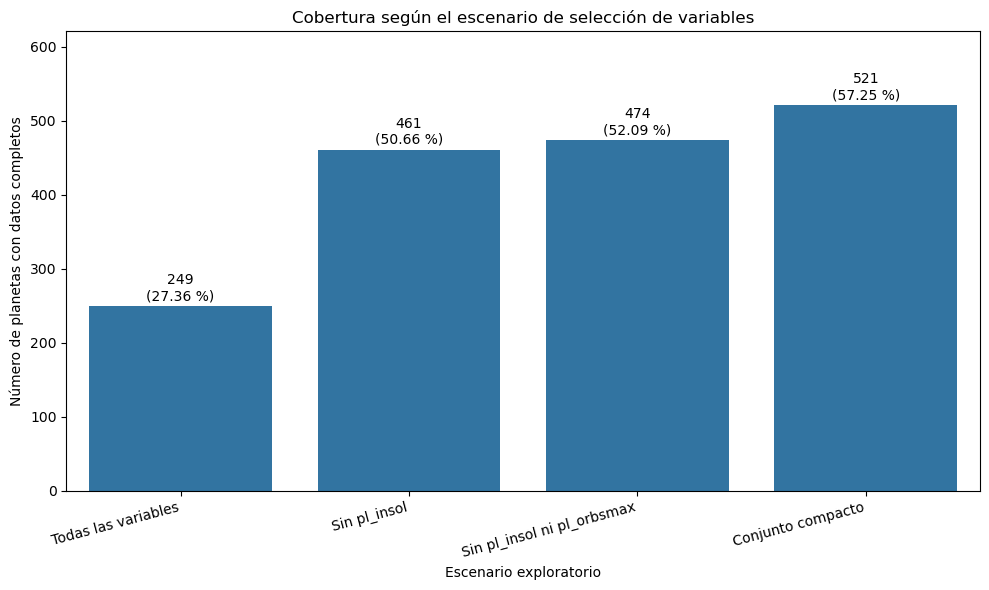

In [30]:
# Representamos el número de planetas completos disponible
# en cada escenario de selección de características.
#
# El objetivo es visualizar cómo cambia el tamaño de la muestra
# al modificar el conjunto de variables exigidas.

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=scenario_comparison,
    x="escenario",
    y="planetas_completos"
)


# Añadimos sobre cada barra el número exacto de observaciones
# y el porcentaje que representan respecto al dataset original.
for i, row in scenario_comparison.iterrows():

    ax.text(
        i,
        row["planetas_completos"] + 8,
        f'{row["planetas_completos"]}\n'
        f'({row["porcentaje_dataset"]:.2f} %)',
        ha="center"
    )


plt.title(
    "Cobertura según el escenario de selección de variables"
)

plt.xlabel(
    "Escenario exploratorio"
)

plt.ylabel(
    "Número de planetas con datos completos"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.ylim(
    0,
    max(scenario_comparison["planetas_completos"]) + 100
)

plt.tight_layout()
plt.show()

## 6. Análisis contextual y posibles sesgos de observación

Además de las características físicas candidatas para el clustering, el dataset contiene variables contextuales relacionadas con el descubrimiento de los exoplanetas.

Estas variables no se consideran inicialmente características destinadas a construir los clusters, pero pueden ayudar a identificar posibles sesgos en la muestra.

Los métodos de detección astronómica no presentan necesariamente la misma sensibilidad ante todos los tipos de planetas. Del mismo modo, la evolución de los instrumentos y técnicas de observación puede haber modificado con el tiempo el tipo de exoplanetas detectados y la cantidad de información disponible sobre ellos.

Por este motivo, se exploran variables como el método y el año de descubrimiento para comprobar si existen patrones que puedan influir en la interpretación posterior de las familias obtenidas mediante clustering.

In [31]:
# Seleccionamos algunas variables contextuales relacionadas
# con el descubrimiento de los exoplanetas.
#
# Estas variables NO se utilizarán inicialmente como features
# para construir los clusters.
#
# Su objetivo en esta sección es ayudarnos a comprender
# cómo está formada la muestra y detectar posibles sesgos
# relacionados con la observación y el descubrimiento.

contextual_features = [
    "discoverymethod",
    "disc_year",
    "disc_facility"
]


# Mostramos para cada variable:
# - número de valores disponibles;
# - número de valores únicos;
# - porcentaje de valores nulos.
#
# Esto nos permite conocer primero la estructura de estas
# variables antes de analizarlas individualmente.

contextual_summary = pd.DataFrame({
    "variable": contextual_features,
    "valores_disponibles": [
        df[col].notna().sum()
        for col in contextual_features
    ],
    "valores_unicos": [
        df[col].nunique()
        for col in contextual_features
    ],
    "porcentaje_nulos": [
        df[col].isna().mean() * 100
        for col in contextual_features
    ]
})


contextual_summary["porcentaje_nulos"] = (
    contextual_summary["porcentaje_nulos"]
    .round(2)
)


contextual_summary

,variable,valores_disponibles,valores_unicos,porcentaje_nulos
0,discoverymethod,910,2,0.0
1,disc_year,910,9,0.0
2,disc_facility,910,1,0.0


In [32]:
# Contamos cuántos exoplanetas corresponden a cada
# método de descubrimiento presente en el dataset.
#
# Esto permite comprobar si la muestra está equilibrada
# entre diferentes técnicas de detección o si está
# dominada por algún método concreto.

discovery_method_counts = (
    df["discoverymethod"]
    .value_counts()
    .rename_axis("metodo_descubrimiento")
    .reset_index(name="numero_planetas")
)


# Calculamos también qué porcentaje del dataset
# representa cada método.
discovery_method_counts["porcentaje"] = (
    discovery_method_counts["numero_planetas"]
    / len(df)
    * 100
).round(2)


discovery_method_counts

,metodo_descubrimiento,numero_planetas,porcentaje
0,Transit,905,99.45
1,Transit Timing Variations,5,0.55


### Interpretación del método de descubrimiento

La muestra presenta un fuerte desequilibrio respecto al método de descubrimiento. De los 910 exoplanetas analizados, 905 (99,45 %) fueron identificados mediante el método de tránsito, mientras que únicamente 5 (0,55 %) aparecen asociados a Transit Timing Variations.

Esta distribución indica que el dataset representa fundamentalmente exoplanetas detectados mediante tránsito, por lo que no puede considerarse una muestra equilibrada de todos los métodos utilizados en la detección de exoplanetas.

Debido al reducido número de observaciones correspondientes a Transit Timing Variations, no se realizan comparaciones estadísticas o gráficas de las propiedades planetarias entre ambos métodos, ya que las diferencias observadas podrían no ser representativas.

Este aspecto deberá tenerse en cuenta al interpretar posteriormente los clusters: las familias identificadas describirán principalmente la estructura existente dentro de esta muestra de exoplanetas detectados por tránsito y no necesariamente la diversidad completa de la población conocida de exoplanetas.

La variable `discoverymethod` se mantiene como información contextual, pero no se considera candidata para construir los clusters.

In [33]:
# Contamos el número de exoplanetas registrados
# para cada año de descubrimiento.
#
# El objetivo es observar la distribución temporal
# de la muestra y detectar posibles concentraciones
# asociadas a determinados periodos de observación.

discoveries_by_year = (
    df["disc_year"]
    .value_counts()
    .sort_index()
    .rename_axis("anio")
    .reset_index(name="numero_planetas")
)


discoveries_by_year

,anio,numero_planetas
0,2018,3
1,2019,33
2,2020,68
3,2021,77
4,2022,111
5,2023,140
6,2024,178
7,2025,129
8,2026,171


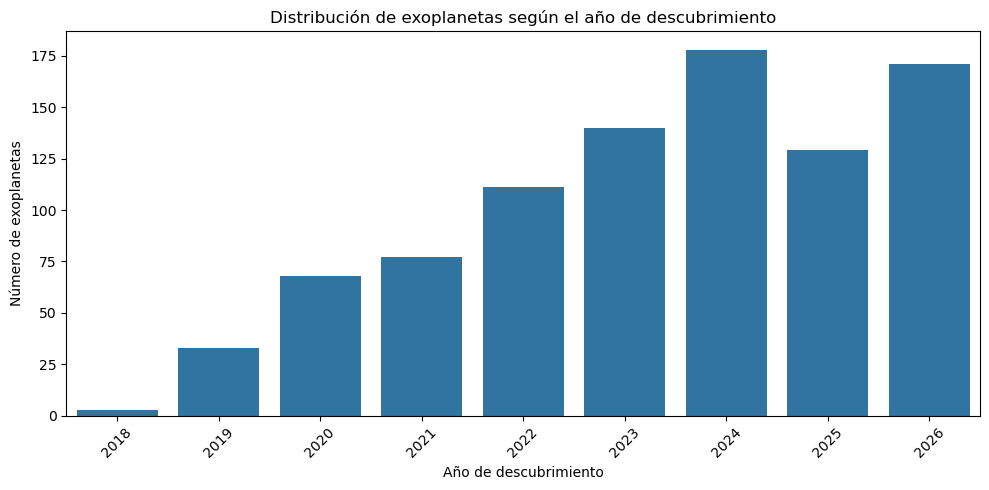

In [34]:
# Representamos la evolución del número de exoplanetas
# de la muestra según su año de descubrimiento.
#
# Esta visualización puede revelar periodos especialmente
# representados en el dataset.

plt.figure(figsize=(10, 5))

sns.barplot(
    data=discoveries_by_year,
    x="anio",
    y="numero_planetas"
)

plt.title(
    "Distribución de exoplanetas según el año de descubrimiento"
)

plt.xlabel(
    "Año de descubrimiento"
)

plt.ylabel(
    "Número de exoplanetas"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Interpretación de la distribución temporal

Los exoplanetas incluidos en el dataset presentan años de descubrimiento comprendidos entre 2018 y 2026, observándose una mayor representación de registros correspondientes a los años más recientes.

Esta distribución temporal no debe interpretarse directamente como la evolución global del número de exoplanetas descubiertos cada año, ya que el dataset constituye una muestra concreta y no necesariamente el catálogo histórico completo de exoplanetas conocidos.

La concentración de observaciones en determinados años puede estar relacionada con el origen y los criterios de construcción del dataset, así como con la evolución de las misiones, instrumentos y procesos de validación de candidatos planetarios.

El año de descubrimiento (`disc_year`) se considera, por tanto, una variable contextual útil para comprender la composición de la muestra, pero no una característica física adecuada para definir las familias de exoplanetas mediante clustering.

### 6.1 Disponibilidad de información según el año de descubrimiento

Además de analizar cuántos exoplanetas de la muestra corresponden a cada año, resulta relevante comprobar si la disponibilidad de las principales variables físicas cambia temporalmente.

Esta exploración permite detectar si los valores ausentes se distribuyen de forma aproximadamente homogénea o si determinadas variables presentan una cobertura diferente según el año de descubrimiento.

Identificar este posible patrón es importante antes del preprocessing, ya que una ausencia de datos asociada al tiempo podría indicar que los valores nulos no se producen completamente al azar.

In [35]:
# Seleccionamos las variables candidatas que presentan
# una cantidad relevante de valores ausentes.
#
# El objetivo es estudiar si su disponibilidad cambia
# según el año de descubrimiento.

coverage_features = [
    "pl_orbsmax",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt",
    "st_mass",
    "st_met"
]


# Calculamos, para cada año, qué porcentaje de los planetas
# dispone de información para cada variable.
#
# notna() convierte cada observación en:
# True  -> existe un valor
# False -> el valor está ausente
#
# Al calcular la media de estos valores booleanos obtenemos
# la proporción de datos disponibles.

coverage_by_year = (
    df.groupby("disc_year")[coverage_features]
    .apply(lambda group: group.notna().mean() * 100)
    .round(2)
)


coverage_by_year

,pl_orbsmax,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_mass,st_met
disc_year,,,,,,,
2018,33.33,66.67,66.67,33.33,66.67,66.67,33.33
2019,72.73,90.91,87.88,36.36,78.79,100.00,78.79
2020,89.71,79.41,92.65,48.53,79.41,98.53,79.41
2021,81.82,85.71,84.42,36.36,75.32,93.51,81.82
2022,84.68,78.38,78.38,50.45,84.68,98.20,90.09
2023,90.71,77.86,82.14,52.86,87.86,100.00,95.71
2024,94.94,70.79,68.54,51.12,78.65,100.00,74.16
2025,86.05,75.97,73.64,54.26,93.02,99.22,92.25
2026,31.58,28.07,26.32,12.28,30.99,33.92,32.75


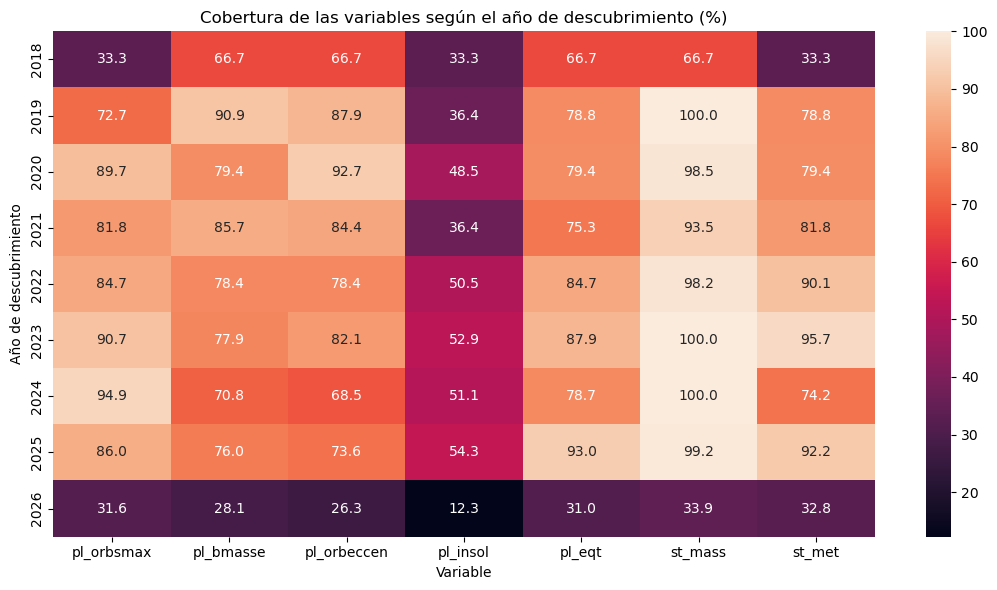

In [36]:
# Representamos mediante un mapa de calor el porcentaje
# de disponibilidad de cada variable según el año.
#
# Los valores más altos indican una mayor cobertura de datos.
# Esta visualización facilita la identificación de posibles
# patrones temporales en los valores ausentes.

plt.figure(figsize=(11, 6))

sns.heatmap(
    coverage_by_year,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Cobertura de las variables según el año de descubrimiento (%)"
)

plt.xlabel(
    "Variable"
)

plt.ylabel(
    "Año de descubrimiento"
)

plt.tight_layout()
plt.show()

### Interpretación de la cobertura temporal

La disponibilidad de las variables analizadas no es homogénea a lo largo de los años de descubrimiento representados en el dataset.

Entre 2019 y 2025, varias características presentan niveles de cobertura relativamente elevados, aunque existen diferencias importantes entre variables. Por ejemplo, `st_mass` mantiene generalmente una disponibilidad muy alta, mientras que `pl_insol` presenta una cobertura considerablemente menor durante todo el periodo.

El año 2026 muestra un comportamiento especialmente diferente, con una caída simultánea y pronunciada de la cobertura en todas las variables analizadas. Por ejemplo, la disponibilidad es del 31,58 % para `pl_orbsmax`, 28,07 % para `pl_bmasse`, 12,28 % para `pl_insol` y 30,99 % para `pl_eqt`.

Este patrón indica que los valores ausentes no se distribuyen de forma uniforme en la muestra y parecen presentar una clara componente temporal, especialmente en los registros correspondientes a 2026.

Por tanto, no sería adecuado asumir automáticamente que todos los valores nulos se producen completamente al azar. Este resultado deberá tenerse en cuenta durante el preprocessing, especialmente al decidir qué variables conservar y qué estrategia utilizar para tratar los valores ausentes.

En esta fase del EDA no se eliminan registros ni se imputan valores; únicamente se documenta el patrón observado para fundamentar las decisiones posteriores de preparación de los datos.

### 6.2 Completitud global de los registros según el año

El análisis anterior ha mostrado una reducción generalizada de la cobertura de múltiples variables en los registros correspondientes a 2026.

Para comprobar si este comportamiento afecta de forma global a los registros, se calcula el número medio de variables candidatas disponibles por planeta en cada año.

Este análisis permite determinar si los registros de determinados periodos presentan, en conjunto, un menor nivel de información disponible.

In [37]:
# Contamos, para cada planeta, cuántas de las 12 variables
# candidatas para el clustering tienen un valor disponible.
#
# El resultado puede variar entre:
# 0  -> ninguna variable disponible
# 12 -> todas las variables disponibles.
#
# Creamos una Serie independiente para no modificar
# el DataFrame original durante el EDA.

available_features_per_planet = (
    df[candidate_features]
    .notna()
    .sum(axis=1)
)


# Agrupamos el número de variables disponibles según
# el año de descubrimiento.
#
# Calculamos:
# - número de planetas de cada año;
# - media de variables disponibles;
# - mediana;
# - mínimo;
# - máximo.
#
# Esto permite comparar el grado general de completitud
# de los registros entre diferentes años.

completeness_by_year = (
    pd.DataFrame({
        "disc_year": df["disc_year"],
        "variables_disponibles": available_features_per_planet
    })
    .groupby("disc_year")["variables_disponibles"]
    .agg(
        numero_planetas="count",
        media_variables_disponibles="mean",
        mediana_variables_disponibles="median",
        minimo="min",
        maximo="max"
    )
    .round(2)
)


completeness_by_year

,numero_planetas,media_variables_disponibles,mediana_variables_disponibles,minimo,maximo
disc_year,,,,,
2018,3,6.67,8.0,0,12
2019,33,10.18,11.0,6,12
2020,68,10.35,11.0,2,12
2021,77,10.18,11.0,5,12
2022,111,10.50,11.0,6,12
2023,140,10.83,11.0,6,12
2024,178,10.17,11.0,6,12
2025,129,10.64,11.0,6,12
2026,171,6.91,5.0,0,12


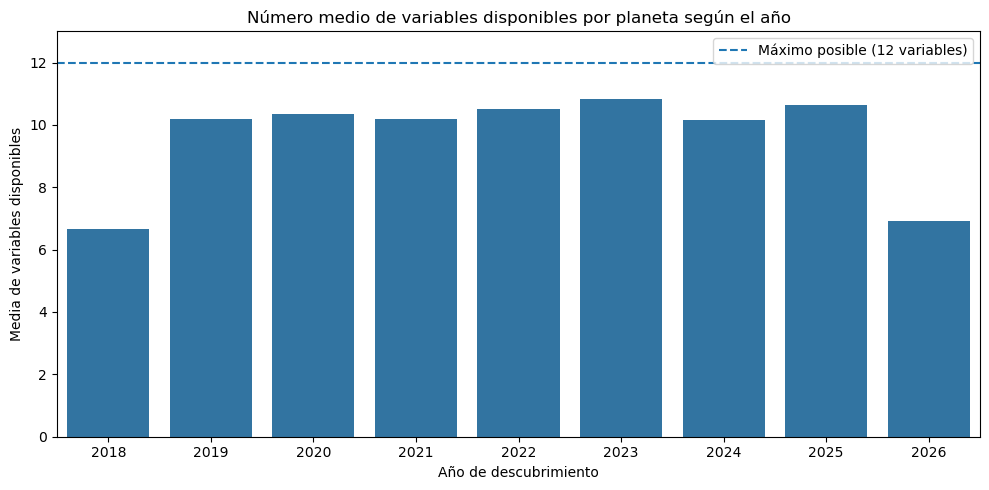

In [38]:
# Representamos el número medio de variables disponibles
# por planeta para cada año de descubrimiento.
#
# Cuanto mayor sea el valor, más completos son en promedio
# los registros correspondientes a ese año.

plt.figure(figsize=(10, 5))

sns.barplot(
    data=completeness_by_year.reset_index(),
    x="disc_year",
    y="media_variables_disponibles"
)

plt.axhline(
    y=len(candidate_features),
    linestyle="--",
    label=f"Máximo posible ({len(candidate_features)} variables)"
)

plt.title(
    "Número medio de variables disponibles por planeta según el año"
)

plt.xlabel(
    "Año de descubrimiento"
)

plt.ylabel(
    "Media de variables disponibles"
)

plt.ylim(
    0,
    len(candidate_features) + 1
)

plt.legend()

plt.tight_layout()
plt.show()

### Interpretación de la completitud global por año

El análisis de completitud confirma que la disponibilidad de información presenta diferencias importantes según el año de descubrimiento.

Entre 2019 y 2025, los registros muestran un nivel de completitud relativamente estable y elevado. Los exoplanetas de estos años disponen, en promedio, de aproximadamente 10 a 11 de las 12 variables candidatas analizadas, con una mediana constante de 11 variables disponibles.

En contraste, los registros correspondientes a 2026 presentan una reducción considerable de información. Los 171 exoplanetas de este año disponen, en promedio, de 6,91 variables candidatas, mientras que la mediana desciende hasta 5. Además, existen registros sin información disponible en ninguna de las 12 variables consideradas para el clustering.

El año 2018 también presenta una completitud media reducida (6,67 variables), aunque únicamente contiene 3 observaciones, por lo que este resultado no permite establecer un patrón generalizable.

En conjunto, los resultados confirman la existencia de un patrón temporal en la completitud de los datos, especialmente relevante en 2026. No obstante, este análisis descriptivo permite identificar la asociación temporal, pero no determinar por sí solo su causa.

Este hallazgo deberá considerarse durante el preprocessing. La eliminación automática de todos los registros incompletos podría afectar de forma desproporcionada a determinados periodos de la muestra, mientras que una imputación indiscriminada podría introducir una cantidad excesiva de información estimada en los registros con menor cobertura.

Por tanto, el tratamiento de los valores ausentes deberá definirse cuidadosamente en la fase de preprocessing, evaluando conjuntamente la cobertura de cada variable, su relevancia para el clustering y el número de observaciones que se conservarían.

# 7. Conclusiones del EDA y consideraciones para el preprocessing

El análisis exploratorio ha permitido estudiar la calidad, distribución, disponibilidad y relaciones existentes entre las variables candidatas para construir las futuras familias de exoplanetas mediante técnicas de clustering.

A partir de los resultados obtenidos se identifican varios aspectos que deberán guiar las decisiones de preprocessing y modelado.

## 7.1 Disponibilidad y valores ausentes

Las variables candidatas presentan niveles de cobertura muy diferentes.

Algunas características, como `pl_orbper`, `st_rad`, `pl_rade` y `st_teff`, presentan una disponibilidad superior al 97 %, mientras que otras contienen una proporción considerable de valores ausentes.

Destacan especialmente:

- `pl_insol`: 42,42 % de cobertura.
- `pl_bmasse`: 68,13 %.
- `pl_orbeccen`: 68,46 %.
- `pl_eqt`: 73,63 %.
- `pl_orbsmax`: 77,36 %.

Utilizar únicamente registros completos para las 12 variables reduciría la muestra de 910 a 249 exoplanetas (27,36 % del dataset).

Por tanto, el tratamiento de los valores ausentes constituye una de las principales decisiones del preprocessing. No resulta conveniente eliminar automáticamente todos los registros incompletos sin evaluar previamente la relevancia de cada variable y la pérdida de información resultante.

## 7.2 Distribuciones y valores extremos

Las variables planetarias presentan distribuciones muy heterogéneas y, en varios casos, fuertemente asimétricas.

Las mayores asimetrías se observan en variables como:

- `pl_orbper`: skewness ≈ 26,28.
- `pl_orbsmax`: skewness ≈ 15,26.
- `pl_bmasse`: skewness ≈ 5,54.
- `pl_insol`: skewness ≈ 3,38.
- `pl_orbeccen`: skewness ≈ 2,22.

El análisis mediante boxplots e IQR también identificó numerosos valores estadísticamente extremos. Sin embargo, en un contexto astrofísico estos valores pueden corresponder a exoplanetas físicamente reales con características poco frecuentes.

Por este motivo, los outliers no deben eliminarse automáticamente.

Las diferencias de escala, la fuerte asimetría y la presencia de valores extremos deberán considerarse antes de aplicar algoritmos de clustering basados en distancias. Será necesario evaluar estrategias de transformación y escalado adecuadas, como transformaciones logarítmicas para determinadas variables y escaladores robustos frente a valores extremos.

## 7.3 Relaciones entre variables y posible redundancia

El análisis de correlaciones mediante Pearson y Spearman ha identificado varias relaciones fuertes entre las variables candidatas.

Entre las asociaciones más relevantes destacan:

- `pl_orbper` y `pl_orbsmax`: Spearman ≈ 0,972.
- `pl_insol` y `pl_eqt`: Spearman ≈ 0,991.
- `st_rad` y `st_mass`: Spearman ≈ 0,966.
- `st_rad` y `st_logg`: Spearman ≈ -0,958.
- `st_teff` y `st_mass`: Spearman ≈ 0,951.
- `st_teff` y `st_rad`: Spearman ≈ 0,923.
- `st_mass` y `st_logg`: Spearman ≈ -0,913.

Estas relaciones indican que algunas variables contienen información estrechamente relacionada.

En clustering, mantener simultáneamente variables muy correlacionadas puede otorgar un peso excesivo a determinadas dimensiones físicas dentro del cálculo de distancias.

Por tanto, durante la selección final de características deberá evaluarse la posible redundancia entre variables, teniendo en cuenta no solo su correlación estadística, sino también su interpretación física y su nivel de cobertura.

## 7.4 Relaciones no lineales y transformaciones

La comparación entre las correlaciones de Pearson y Spearman ha permitido detectar relaciones monotónicas que no siempre se representan adecuadamente mediante una relación lineal.

Un ejemplo especialmente relevante es la relación entre el radio (`pl_rade`) y la masa planetaria (`pl_bmasse`), cuya correlación de Pearson es moderada (≈ 0,329), mientras que Spearman alcanza un valor elevado (≈ 0,886).

Las visualizaciones en escala logarítmica mostraron además una estructura más clara en relaciones como:

- periodo orbital y semieje mayor;
- radio y masa planetaria.

Estos resultados sugieren que algunas variables podrían beneficiarse de transformaciones antes del clustering.

La conveniencia de aplicar transformaciones logarítmicas u otras estrategias se evaluará durante el preprocessing, sin modificar los datos originales durante esta fase exploratoria.

## 7.5 Contexto y representatividad de la muestra

El análisis contextual muestra que el dataset está fuertemente dominado por exoplanetas asociados al método de tránsito.

De los 910 registros:

- 905 (99,45 %) corresponden a `Transit`.
- 5 (0,55 %) corresponden a `Transit Timing Variations`.

Por tanto, las familias obtenidas mediante clustering deberán interpretarse como patrones existentes dentro de la población representada por este dataset y no necesariamente como una clasificación completa de toda la diversidad conocida de exoplanetas.

También se ha identificado un patrón temporal en la disponibilidad de información. Los registros comprendidos entre 2019 y 2025 presentan, en general, alrededor de 10-11 variables candidatas disponibles de media, mientras que los 171 registros correspondientes a 2026 presentan únicamente 6,91 variables de media y una mediana de 5.

Este patrón indica que la ausencia de datos no se distribuye homogéneamente en la muestra, aspecto que deberá tenerse en cuenta al diseñar la estrategia de tratamiento de valores ausentes.

## 7.6 Síntesis de hallazgos y próximos pasos

La siguiente tabla resume los principales hallazgos obtenidos durante el EDA y su implicación para las siguientes fases del proyecto.

In [39]:
# Resumimos los principales hallazgos obtenidos durante el EDA
# y su implicación para las siguientes fases del proyecto.
#
# Esta tabla NO ejecuta ninguna transformación sobre los datos.
# Su objetivo es documentar cómo los resultados del análisis
# exploratorio guiarán las decisiones posteriores.

eda_conclusions = pd.DataFrame({

    "hallazgo": [
        "Cobertura desigual y presencia elevada de valores nulos",
        "Fuerte asimetría en varias variables",
        "Presencia de numerosos valores extremos",
        "Variables con escalas numéricas muy diferentes",
        "Correlaciones muy fuertes entre algunas características",
        "Relaciones monotónicas y no lineales",
        "Baja cobertura de pl_insol",
        "Menor completitud de los registros de 2026",
        "Muestra dominada por el método de tránsito"
    ],

    "implicacion": [
        "Evaluar selección de variables e imputación antes de eliminar registros",
        "Evaluar transformaciones como log1p en variables positivas muy sesgadas",
        "No eliminar outliers automáticamente y considerar escalado robusto",
        "Aplicar escalado antes de utilizar clustering basado en distancias",
        "Evaluar redundancia para evitar sobrerrepresentar dimensiones físicas",
        "No depender únicamente de relaciones lineales para seleccionar variables",
        "Valorar su exclusión del clustering principal o su uso en análisis complementarios",
        "Evitar una eliminación indiscriminada de filas incompletas y estudiar el tratamiento de nulos",
        "Interpretar los clusters dentro del contexto y limitaciones de la muestra"
    ]
})


eda_conclusions

,hallazgo,implicacion
0,Cobertura desigual y presencia elevada de valo...,Evaluar selección de variables e imputación an...
1,Fuerte asimetría en varias variables,Evaluar transformaciones como log1p en variabl...
2,Presencia de numerosos valores extremos,No eliminar outliers automáticamente y conside...
3,Variables con escalas numéricas muy diferentes,Aplicar escalado antes de utilizar clustering ...
4,Correlaciones muy fuertes entre algunas caract...,Evaluar redundancia para evitar sobrerrepresen...
5,Relaciones monotónicas y no lineales,No depender únicamente de relaciones lineales ...
6,Baja cobertura de pl_insol,Valorar su exclusión del clustering principal ...
7,Menor completitud de los registros de 2026,Evitar una eliminación indiscriminada de filas...
8,Muestra dominada por el método de tránsito,Interpretar los clusters dentro del contexto y...


## Conclusión final

El EDA muestra que el dataset contiene información suficiente para explorar la existencia de familias de exoplanetas mediante clustering, pero requiere una fase de preprocessing cuidadosamente diseñada.

Los principales retos identificados son la presencia desigual de valores ausentes, las fuertes diferencias de escala, la asimetría de varias variables, la existencia de valores extremos físicamente plausibles y la elevada correlación entre determinadas características.

Los resultados también muestran que utilizar las 12 variables candidatas simultáneamente reduciría considerablemente la muestra disponible. Por ello, la selección final de características deberá buscar un equilibrio entre riqueza física, redundancia estadística y conservación de observaciones.

A partir de estos resultados, la siguiente fase del proyecto deberá evaluar diferentes estrategias de selección de variables, tratamiento de valores ausentes, transformación y escalado antes de aplicar los algoritmos de clustering.

El objetivo será construir una representación de los exoplanetas que conserve la mayor cantidad posible de información física relevante sin introducir sesgos innecesarios ni otorgar un peso desproporcionado a determinadas variables.